## Table of content
1. [Data Cleaning](#cleaning_section)
2. [Data Understanding](#understanding_section)
   * [2.1 Column Description](#column_section)
   * [2.2 Explicit Songs Analysis](#explicit_section)
     * [2.2.1 Explicit Boxplot](#explicit_boxplot_section)
     * [2.2.2 Analysis of the categorical feature 'mode'](#explicit_feature_mode_section)
     * [2.2.3 Numerical analysis: average values](#explicit_numerical_section)
     * [2.2.4 Decision Tree Classifier analysis](#explicit_decisiontree_section)
     * [2.2.5 Logistic Regression Model: Bar Plot](#explicit_logisticreg_barplot_section)
     * [2.2.6 Joint Plot Relationship between Speechiness and Instrumentalness](#explicit_jointplot_section)
     * [2.2.7 Studying explicit and non-explicit samples](#explicit_samples_section)
   * [2.3 Songs's Popularity Analysis](#popularity_section)
     * [2.3.1 Popularity Numerical analysis](#popularity_numerical_section)
     * [2.3.2 Features Correlation Matrix](#popularity_cormatrix_section)
     * [2.3.3 Top-3 Audio Features Impact on Popularity](#popularity_top3_section)
     * [2.3.4 Categorical Features Analysis for Popularity](#popularity_violinplot_section)
     * [2.3.5 Random Forest Model: Feature Importance for Predicting Popularity](#popularity_randomforest_featuresimportance_section)
     * [2.3.6 Random Forest Model: Partial Dependence Plots (How features isolate their impact on Popularity)](#popularity_randomforest_partialdependence_section)
     * [2.3.7 Random Forest Model: SHAP Summary Plot — Non-linear Impact Features Matrix](#popularity_randomforest_shap_section)
   * [2.4 Track's Duration Analysis](#duration_section)
     * [2.4.1 Duration Numerical analysis](#duration_numerical_section)
     * [2.4.2 Duration Distribution and Popularity Dependency Graphs](#duration_dist_pop_section)
     * [2.4.3 Random Forest Model: Feature Importance including Track Duration](#duration_randomforest_featureimp_section)
     * [2.4.4 Random Forest Model: Partial Dependence Plot Pure Impact of Track Duration on Popularity](#duration_randomforest_pureimpact_section)
     * [2.4.5 Random Forest Model: SHAP Summary Plot with Duration Factor](#duration_randomforest_shap_section)
3. [Executive Summary & Key Takeaways](#executive_summary_section)

In [1]:
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
import numpy as np
plt.style.use('ggplot')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split
import shap

C:\Users\igory\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloading Raw Data Frame:

In [2]:
df_raw = pd.read_csv("hf://datasets/maharshipandya/spotify-tracks-dataset/dataset.csv", index_col=0)
df_raw

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


<a id="cleaning_section"></a>
# Data Cleaning

In [3]:
df_raw.loc[df_raw.duplicated(keep=False)] # We can see 450 rows dealing 894 duplicated rows in a dataset. So let's drop duplicates. 

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1874,0CDucx9lKxuCZplLXUz0iX,Buena Onda Reggae Club,Disco 2,Song for Rollins,16,219346,False,0.841,0.577,0,-7.544,1,0.0438,0.238000,0.860000,0.0571,0.843,90.522,4,afrobeat
1925,0CDucx9lKxuCZplLXUz0iX,Buena Onda Reggae Club,Disco 2,Song for Rollins,16,219346,False,0.841,0.577,0,-7.544,1,0.0438,0.238000,0.860000,0.0571,0.843,90.522,4,afrobeat
2109,2aibwv5hGXSgw7Yru8IYTO,Red Hot Chili Peppers,Stadium Arcadium,Snow (Hey Oh),80,334666,False,0.427,0.900,11,-3.674,1,0.0499,0.116000,0.000017,0.1190,0.599,104.655,4,alt-rock
2155,2aibwv5hGXSgw7Yru8IYTO,Red Hot Chili Peppers,Stadium Arcadium,Snow (Hey Oh),80,334666,False,0.427,0.900,11,-3.674,1,0.0499,0.116000,0.000017,0.1190,0.599,104.655,4,alt-rock
3683,7mULVp0DJrI2Nd6GesLvxn,Joy Division,Timeless Rock Hits,Love Will Tear Us Apart,0,204621,False,0.524,0.902,2,-8.662,1,0.0368,0.000989,0.695000,0.1370,0.907,146.833,4,alternative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111980,46FPub2Fewe7XrgM0smTYI,Morcheeba,Parts of the Process,Undress Me Now,17,203773,False,0.576,0.352,7,-10.773,0,0.0268,0.700000,0.270000,0.1600,0.360,95.484,4,trip-hop
112931,6qVA1MqDrDKfk9144bhoKp,Acil Servis,Küçük Adam,Bebek,38,319933,False,0.486,0.485,5,-12.391,0,0.0331,0.004460,0.000017,0.3690,0.353,120.095,4,turkish
112968,6qVA1MqDrDKfk9144bhoKp,Acil Servis,Küçük Adam,Bebek,38,319933,False,0.486,0.485,5,-12.391,0,0.0331,0.004460,0.000017,0.3690,0.353,120.095,4,turkish
113295,5WaioelSGekDk3UNQy8zaw,Matt Redman,Sing Like Never Before: The Essential Collection,Our God - New Recording,34,265373,False,0.487,0.895,11,-5.061,1,0.0413,0.000183,0.000000,0.3590,0.384,105.021,4,world-music


In [4]:
df=df_raw.drop_duplicates()

<a id="understanding_section"></a>
# Data Undertanding

In [5]:
print("Dataset shape:", df.shape)
print("Dataset Information:", df.info)

Dataset shape: (113550, 20)
Dataset Information: <bound method DataFrame.info of                       track_id                 artists  \
0       5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1       4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2       1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3       6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4       5vjLSffimiIP26QG5WcN2K        Chord Overstreet   
...                        ...                     ...   
113995  2C3TZjDRiAzdyViavDJ217           Rainy Lullaby   
113996  1hIz5L4IB9hN3WRYPOCGPw           Rainy Lullaby   
113997  6x8ZfSoqDjuNa5SVP5QjvX           Cesária Evora   
113998  2e6sXL2bYv4bSz6VTdnfLs        Michael W. Smith   
113999  2hETkH7cOfqmz3LqZDHZf5           Cesária Evora   

                                               album_name  \
0                                                  Comedy   
1                                        Ghost (Acoustic)   
2                                      

In [6]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113550.000000,1.135500e+05,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000
mean,33.324139,2.280794e+05,0.567031,0.642090,5.309467,-8.243419,0.637860,0.084674,0.314067,0.155702,0.213611,0.474207,122.175888,3.904218
std,22.283976,1.064148e+05,0.173408,0.251052,3.560134,5.011401,0.480621,0.105761,0.331907,0.309216,0.190461,0.259204,29.972861,0.432115
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.741802e+05,0.456000,0.473000,2.000000,-9.997750,0.000000,0.035900,0.016800,0.000000,0.098000,0.260000,99.296500,4.000000
50%,35.000000,2.130000e+05,0.580000,0.685000,5.000000,-6.997000,1.000000,0.048900,0.168000,0.000041,0.132000,0.464000,122.020000,4.000000
75%,50.000000,2.615878e+05,0.695000,0.854000,8.000000,-5.001000,1.000000,0.084500,0.596000,0.048675,0.273000,0.683000,140.073750,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [7]:
df['duration_ms'].unique()

array([230666, 149610, 210826, ..., 250629, 312566, 271466],
      shape=(50697,))

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113550 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113550 non-null  object 
 1   artists           113549 non-null  object 
 2   album_name        113549 non-null  object 
 3   track_name        113549 non-null  object 
 4   popularity        113550 non-null  int64  
 5   duration_ms       113550 non-null  int64  
 6   explicit          113550 non-null  bool   
 7   danceability      113550 non-null  float64
 8   energy            113550 non-null  float64
 9   key               113550 non-null  int64  
 10  loudness          113550 non-null  float64
 11  mode              113550 non-null  int64  
 12  speechiness       113550 non-null  float64
 13  acousticness      113550 non-null  float64
 14  instrumentalness  113550 non-null  float64
 15  liveness          113550 non-null  float64
 16  valence           113550 

In [9]:
df.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

<a id="column_section"></a>
# Column Description

In [10]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

- **track_id**: The Spotify ID for the track.

- **artists**: The names of the artists who performed the track. If there is more than one artist, their names are separated by a `;`.

- **album_name**: The name of the album in which the track appears.

- **track_name**: The name of the track.

- **popularity**: A value between **0 and 100**, where **100 represents the most popular tracks**. Popularity is calculated algorithmically and is based primarily on the total number of plays and how recent those plays are. Generally, songs that are played frequently now will have higher popularity than songs that were popular in the past. Duplicate tracks, such as the same song appearing on both a single and an album, are rated independently.

- **duration_ms**: The duration of the track in milliseconds.

- **explicit**: Indicates whether the track contains explicit lyrics:
  - `true` — explicit lyrics are present.
  - `false` — no explicit lyrics or the information is unknown.

- **danceability**: Describes how suitable a track is for dancing based on musical elements such as tempo, rhythm stability, beat strength, and overall regularity. Values range from `0.0` (least danceable) to `1.0` (most danceable).

- **energy**: A measure of intensity and activity ranging from `0.0` to `1.0`. High-energy tracks typically feel fast, loud, and intense, while low-energy tracks tend to be calmer and softer.

- **key**: The musical key of the track. Integers correspond to pitches using standard Pitch Class notation:
  - `0 = C`
  - `1 = C♯/D♭`
  - `2 = D`
  - `...`
  - `11 = B`
  - `-1` indicates that no key was detected.

- **loudness**: The overall loudness of a track, measured in decibels (`dB`).

- **mode**: Indicates the modality of the track:
  - `1` — major.
  - `0` — minor.

- **speechiness**: Detects the presence of spoken words in a track.
  - Values above `0.66` typically indicate tracks consisting primarily of spoken words.
  - Values between `0.33` and `0.66` may indicate a combination of music and speech, such as rap.
  - Values below `0.33` most likely represent music with little or no spoken content.

- **acousticness**: A confidence measure ranging from `0.0` to `1.0` that indicates whether a track is acoustic. A value of `1.0` represents high confidence that the track is acoustic.

- **instrumentalness**: Predicts whether a track contains no vocals. Values closer to `1.0` indicate a higher probability that the track is instrumental.

- **liveness**: Detects the presence of an audience in the recording. Higher values indicate a greater probability that the track was performed live. Values above `0.8` provide a strong indication of a live performance.

- **valence**: A measure ranging from `0.0` to `1.0` that describes the musical positiveness conveyed by a track. Higher values indicate more positive, happy, or cheerful sounds, while lower values indicate more negative, sad, or angry sounds.

- **tempo**: The estimated tempo of the track, measured in beats per minute (`BPM`).

- **time_signature**: The estimated time signature of the track. Values typically range from `3` to `7`, representing time signatures such as `3/4`, `4/4`, `5/4`, `6/4`, and `7/4`.

- **track_genre**: The genre to which the track belongs.

In [11]:
df['duration_minutes'] = df['duration_ms'] / 1000 / 60
df['duration_seconds'] = df['duration_ms'] / 1000
components = pd.to_timedelta(df['duration_ms'], unit='ms').dt.components
df['duration'] = (
    components['minutes'].astype(str).str.zfill(2) + ":" + 
    components['seconds'].astype(str).str.zfill(2)
)

C:\Users\igory\AppData\Local\Temp\ipykernel_22376\794173657.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['duration_minutes'] = df['duration_ms'] / 1000 / 60
C:\Users\igory\AppData\Local\Temp\ipykernel_22376\794173657.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['duration_seconds'] = df['duration_ms'] / 1000
C:\Users\igory\AppData\Local\Temp\ipykernel_22376\794173657.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

In [12]:
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_minutes,duration_seconds,duration
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,3.844433,230.666,03:50
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,2.493500,149.610,02:29
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,3.513767,210.826,03:30
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,3.365550,201.933,03:21
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,3.314217,198.853,03:18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,...,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,6.416650,384.999,06:24
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,...,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,6.416667,385.000,06:25
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,...,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,4.524433,271.466,04:31
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,...,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,4.731550,283.893,04:43


<a id="explicit_section"></a>
# Explicit songs analysis:

In [13]:
y = df_raw['explicit'].value_counts()

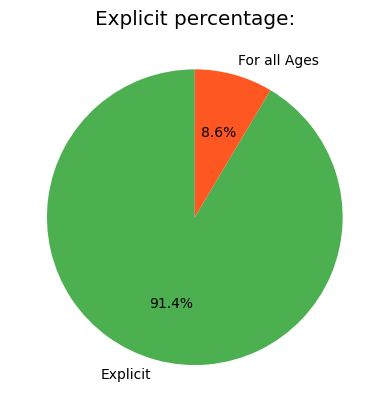

In [14]:
plt.pie(y, 
        autopct="%1.1f%%",  # Displays percentages on the wedges
        startangle=90,  # Rotates the start of the pie for a cleaner look
        colors=["#4CAF50", "#FF5722"],  # Custom colours (Optional: Green for Explicit, Red for not Explicit)
        labels=["Explicit", "For all Ages"],  # Explicitly label the slices
    )
plt.title("Explicit percentage:")
plt.ylabel("")  # Removes the default column name label on the side

plt.show()

From this diagram we can see that over 90% of the songs being explicit and only 8.6% of all songs can be played around childrens. In that case we can clearly see that main audience of Spotify services mainly adult.

What makes explicit songs explicit? \
Let's do the research about Explicit parameter depended on continuos features:
<a id="explicit_boxplot_section"></a>

In [15]:
continuous_features = ['loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

C:\Users\igory\AppData\Local\Temp\ipykernel_22376\2482658711.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='explicit', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\igory\AppData\Local\Temp\ipykernel_22376\2482658711.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='explicit', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\igory\AppData\Local\Temp\ipykernel_22376\2482658711.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='explicit', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\igory\AppData\Local\Temp\

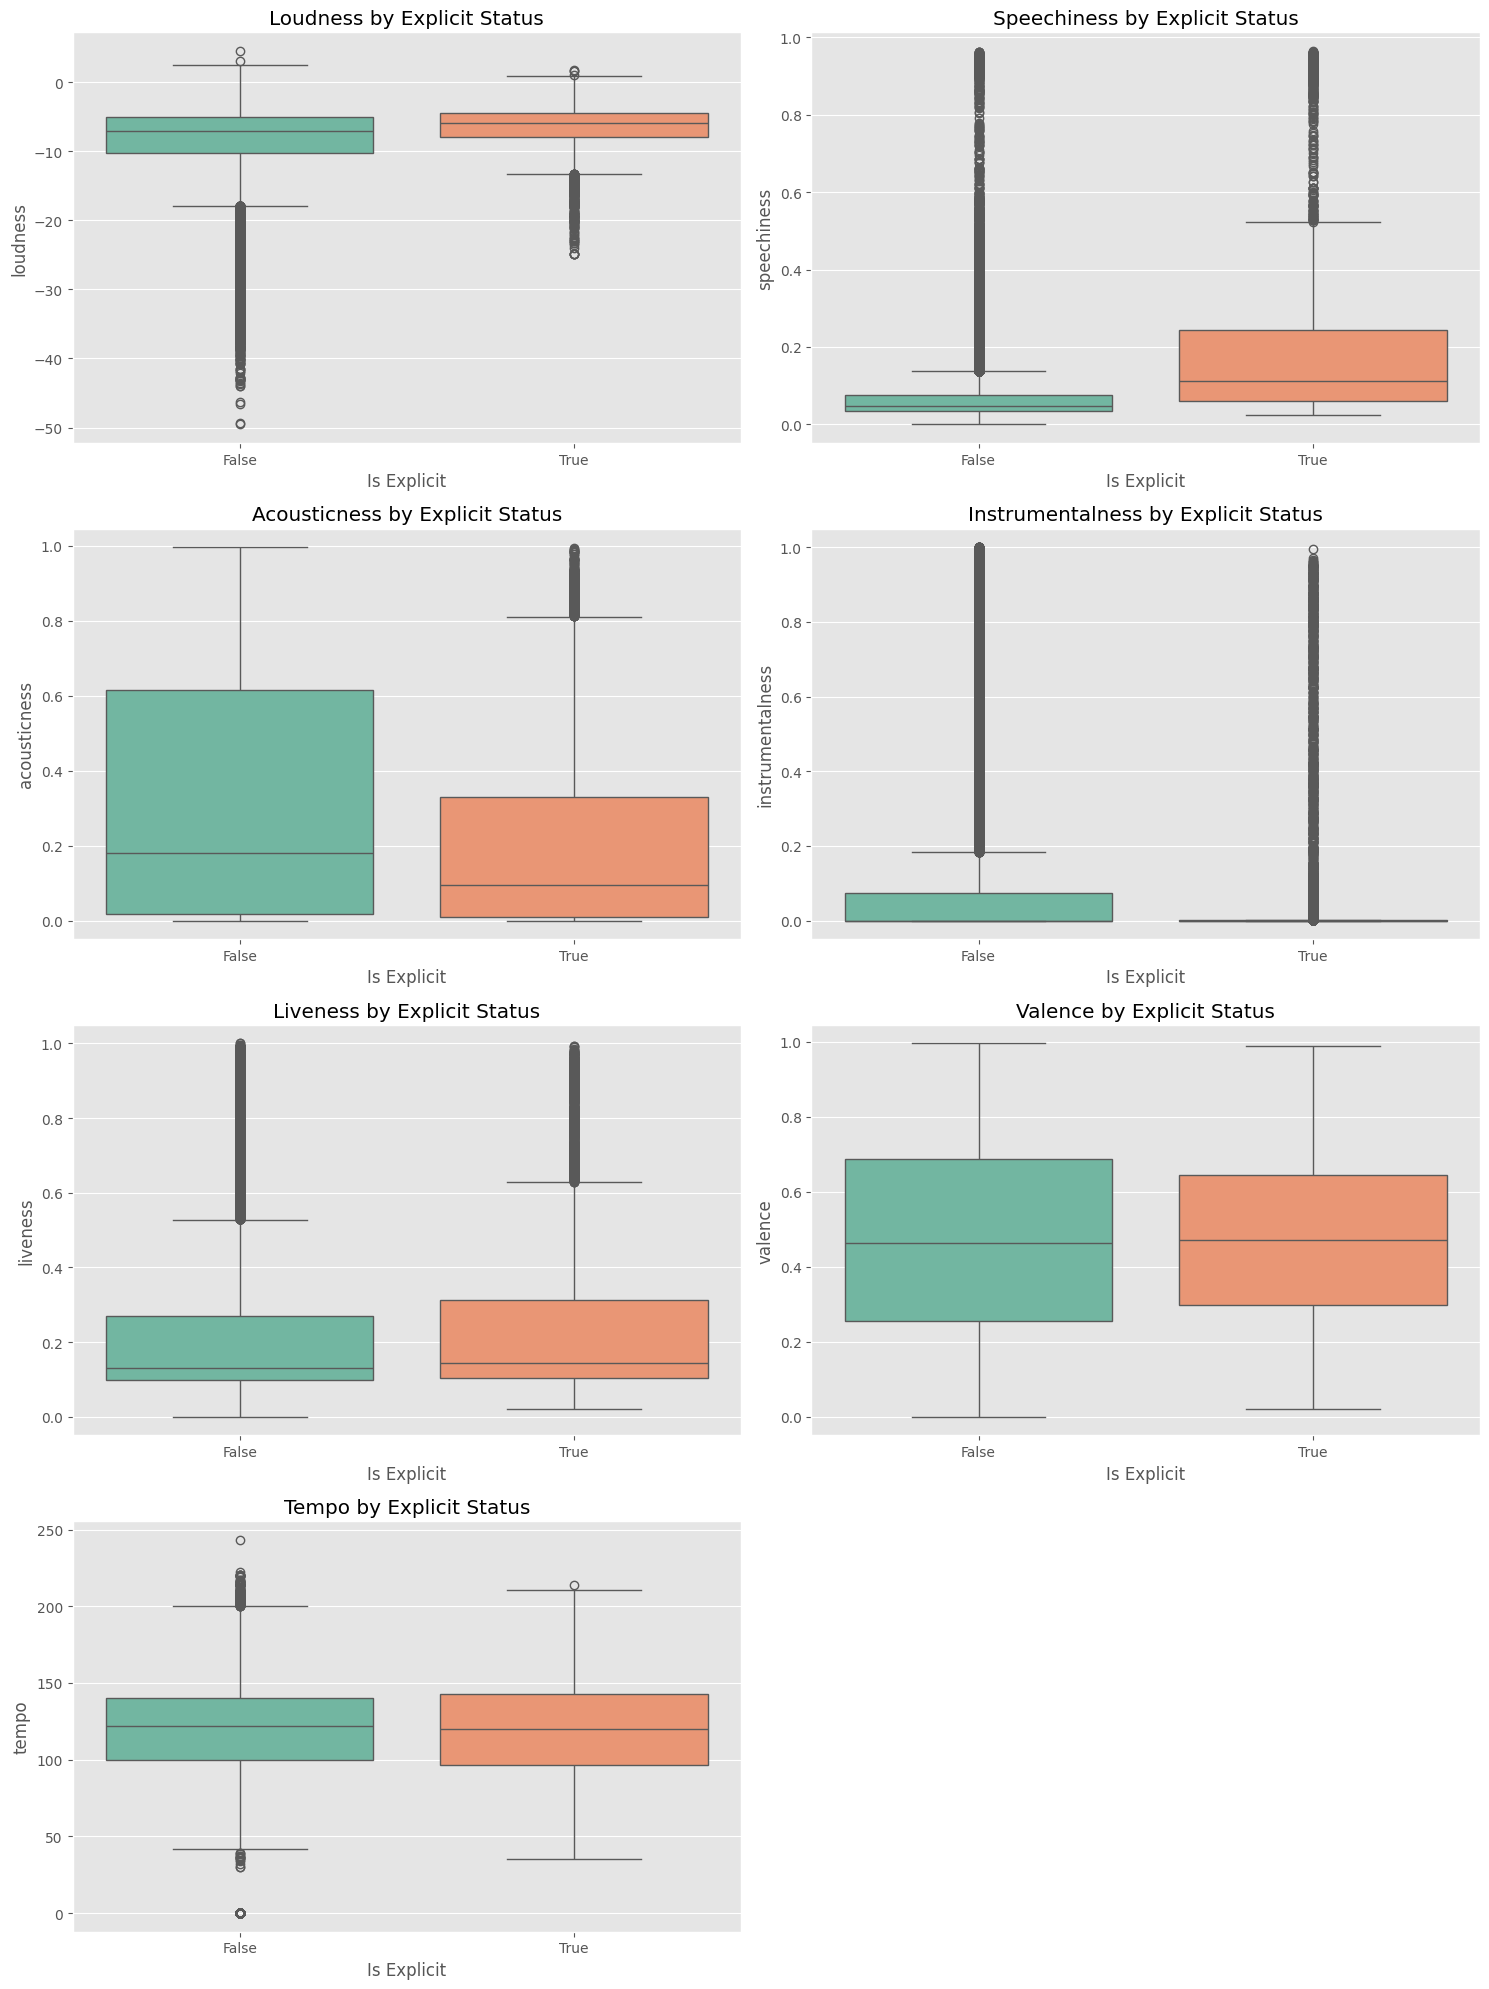

In [16]:
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    # Creating a boxplot to compare medians and dispersion
    sns.boxplot(x='explicit', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(col.capitalize() + ' by Explicit Status')
    axes[i].set_xlabel('Is Explicit')
    axes[i].set_ylabel(col)

# We delete the last (eighth) empty graph, since there are 7 features
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

From this boxplots we can see that the most interesting features that affect explicit status is **speechiness**, **instrumentalness**, **acousticness** and **loudness** \
But let's continue our research...

<a id="explicit_feature_mode_section"></a>

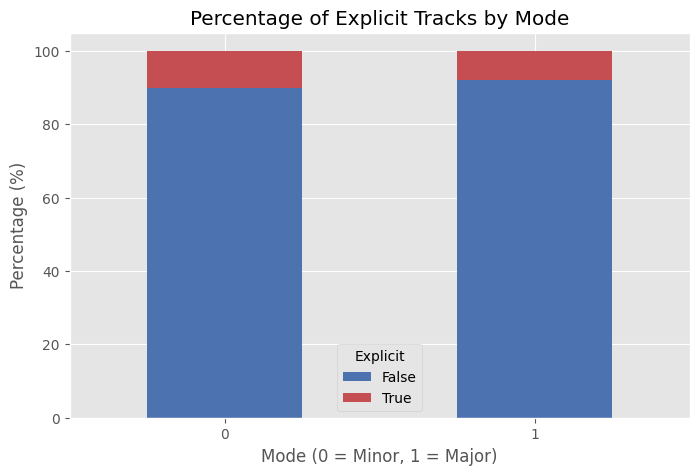

In [17]:
# 2. Analysis of the categorical feature 'mode'
mode_explicit = pd.crosstab(df['mode'], df['explicit'], normalize='index') * 100
mode_explicit.plot(kind='bar', stacked=True, color=['#4c72b0', '#c44e52'], figsize=(8, 5))
plt.title('Percentage of Explicit Tracks by Mode')
plt.xlabel('Mode (0 = Minor, 1 = Major)')
plt.ylabel('Percentage (%)')
plt.legend(title='Explicit')
plt.xticks(rotation=0)
plt.show()

From this graph we could not see much difference between both explicit and non-explicit factors by **Mode** \
Let's continue...

<a id="explicit_numerical_section"></a>

In [18]:
# 3. Numerical analysis: average values
print("Mean values grouped by Explicit status:")
print(df.groupby('explicit')[continuous_features].mean().T)

Mean values grouped by Explicit status:
explicit               False       True 
loudness           -8.408980   -6.474483
speechiness         0.074726    0.190962
acousticness        0.323586    0.212357
instrumentalness    0.165461    0.051427
liveness            0.211725    0.233763
valence             0.474507    0.471003
tempo             122.204296  121.872358


Based on the calculated averages, we can draw several key conclusions about the nature of "explicit" tracks. \ 
The features fall into three distinct groups based on the degree of influence: 
1. Strong correlation (Primary explicit markers): 
   - **speechiness**: This metric is 2.5 times higher for explicit tracks (0.191 vs. 0.074). It is the most prominent marker. Such tracks contain significantly more lyrics and spoken word, which is characteristic of rap, hip-hop, and spoken-word genres. 
   - **instrumentalness**: This metric is 3 times lower for explicit tracks (0.051 vs. 0.165). The logical conclusion is that tracks containing profanity are almost never purely instrumental; they almost always feature vocals. 
   - **acousticness**: This is noticeably lower for explicit tracks (0.212 vs. 0.324). This suggests that tracks with explicit lyrics are more likely to be created using electronic or synthesized instruments rather than acoustic ones (like guitars or pianos). 
2. Moderate correlation: 
   - **loudness**: Explicit tracks are louder on average (-6.47 dB vs. -8.42 dB; remember that the scale is negative, so values ​​closer to 0 indicate greater loudness). This confirms the hypothesis that explicit content is more common in genres that are more aggressive, dynamic, and sonically "pumped up" for commercial appeal. 
   - **liveness**: The difference is slight, but the metric is marginally higher for explicit tracks (0.233 vs. 0.211). This may be due to a greater presence of "live" vocal effects or background noise. 
3. No correlation (Neutral features): 
   - **tempo**: The average tempo is virtually identical for both groups (~122 BPM). The tempo of the music is unrelated to the presence of explicit lyrics. Valence (musical positivity): The values ​​are identical (~0.47). Explicit tracks can be sad/somber or cheerful in exactly the same proportions as standard songs.

<a id="explicit_decisiontree_section"></a>

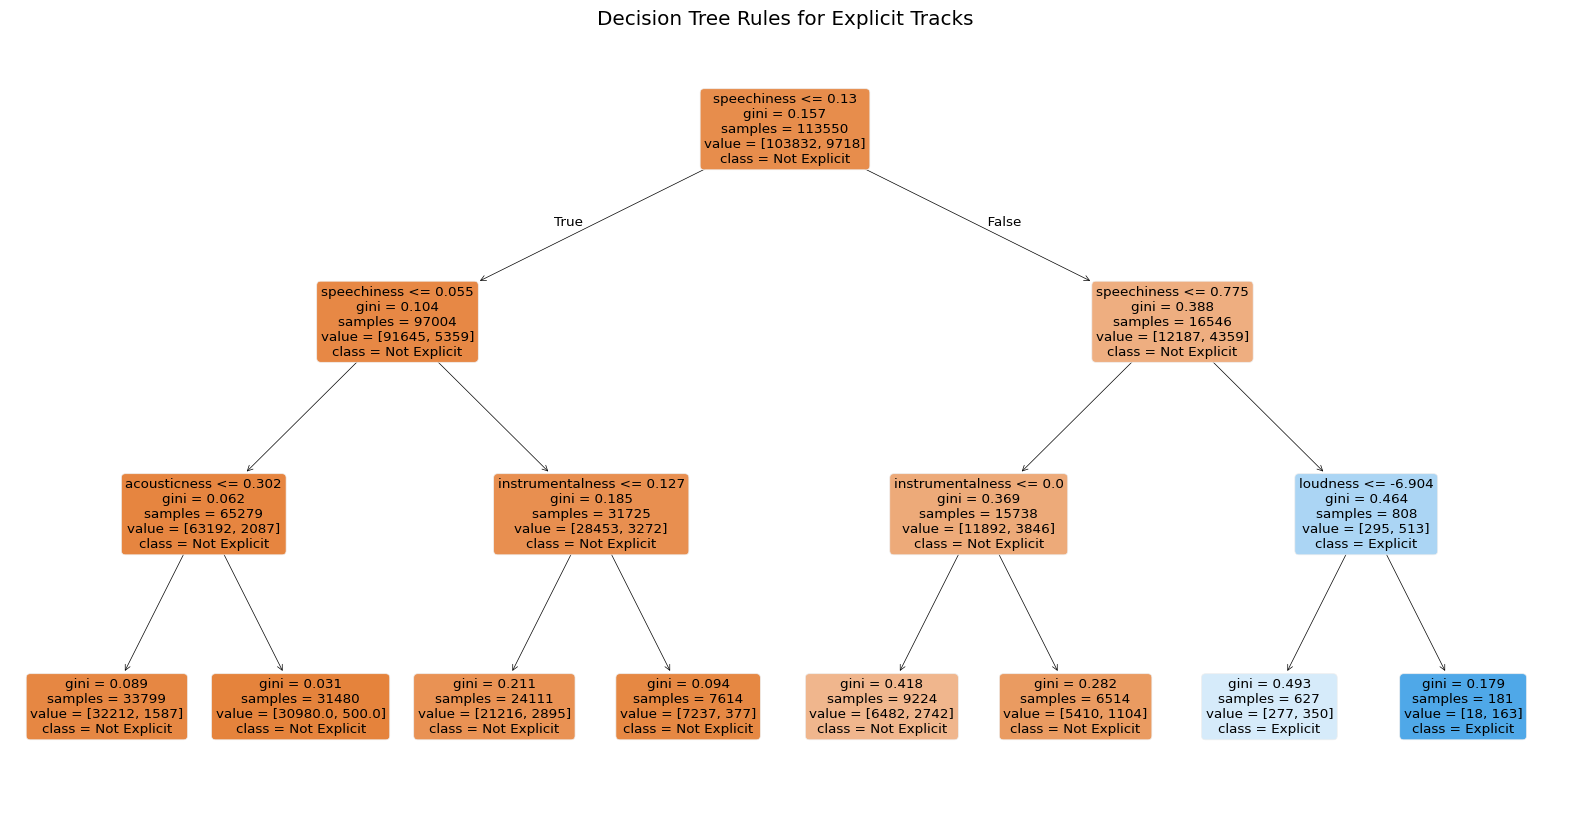

In [19]:
# Selecting features and the target variable
features = ['loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
X = df[features]
y = df['explicit'].astype(int) # convert True/False to 1/0

# Limiting the depth to make the tree readable and clear
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X, y)

# Tree visualization
plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=features, class_names=['Not Explicit', 'Explicit'], filled=True, rounded=True)
plt.title("Decision Tree Rules for Explicit Tracks")
plt.show()

Based on this decision tree, we can draw very clear conclusions about the logic behind track classification—insights.\
The model confirmed our previous hypotheses and identified specific numerical thresholds:
1. The primary splitting factor (Root node): 
- `speechiness <= 0.13` — this is the tree's very first and most important rule. 
- Note that 91.4% of all tracks in the dataset (104,253 out of 114,000) are initially classified as **"Not Explicit."** 
- The model immediately splits the data: if `speechiness > 0.13` (moving to the right), the concentration of explicit tracks rises sharply. Of the 16,603 tracks in the right branch, 4,379 are explicit (about 26%, which is far higher than the dataset average). 
2. Finding "pure" explicit content (Right branch): 
- Moving right along the tree (`speechiness > 0.13`), the next key threshold is `speechiness <= 0.775`. 
- If `speechiness > 0.775` (moving to the far-right branch), we encounter tracks consisting almost entirely of spoken words (e.g., podcasts, audiobooks, or a cappella rap). Here, the model checks loudness (`loudness <= -6.904`). 
- If such a "highly spoken" track is loud (`loudness > -6.904`), we land in the far-right blue leaf node: out of 181 tracks, 163 are explicit (90%). This is the "purest" zone for explicit content in the dataset. 
3. Where there are virtually no Explicit tracks (left branch): 
- If we move to the left along the tree (speechiness <= 0.13), the majority of these tracks (at the far left) are classified as Not Explicit. 
- It is interesting to examine the checks for acousticness <= 0.302 and instrumentalness <= 0.127. The model confirms that if a track is instrumental (instrumentalness > 0.127), the probability of encountering explicit lyrics drops to a minimum (with only 377 explicit tracks out of 7,645 in the corresponding leaf node).

<a id="explicit_logisticreg_barplot_section"></a>

C:\Users\igory\AppData\Local\Temp\ipykernel_22376\3797927885.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='vlag')


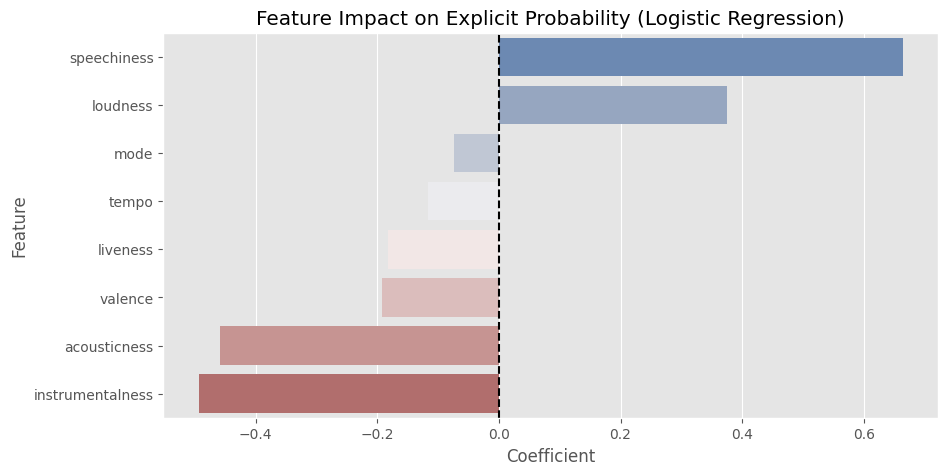

In [20]:
# Feature scaling is essential for a valid comparison of weights.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_scaled, y)

# Create a dataframe with coefficients
importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

# Visualizing Importance
plt.figure(figsize=(10, 5))
sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='vlag')
plt.title('Feature Impact on Explicit Probability (Logistic Regression)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

As we can see by logistic regression, the explicit factor mostly relies on **higher speechiness** and **loudness** features and **lower instrumentalness** and **valence**, which is as expected for explicit content with more words in texts and more loud and angry tones of music. \ 
Specifically, the model reveals that:
- Speechiness is the single strongest predictor (`coefficient ~0.65`), confirming that explicit tracks are heavily driven by spoken words and lyrics rather than melody alone.
- Loudness acts as a major catalyst, suggesting that non-explicit tracks tend to be quieter, while explicit content thrives in louder, high-energy productions.
- Instrumentalness and acousticness show strong negative impacts (`coefficients around -0.5`), mathematically proving that explicit tracks are rarely acoustic and almost never purely instrumental.
- A lower valence (`negative coefficient`) further highlights that explicit songs lean slightly towards more aggressive, melancholic, or serious moods rather than cheerful vibes.

<a id="explicit_jointplot_section"></a>

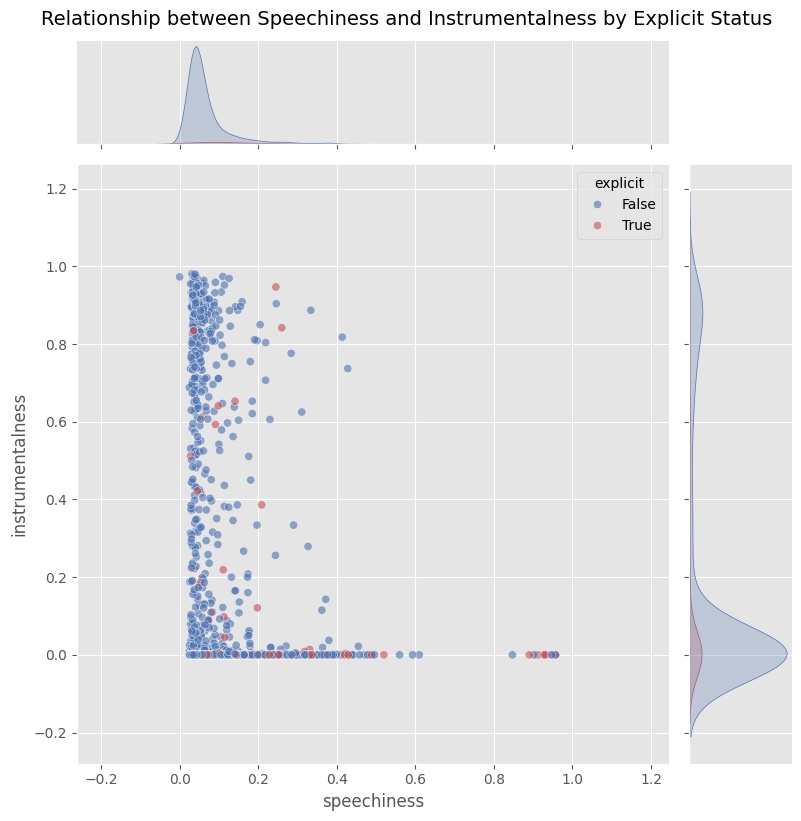

In [21]:
# Take a random sample so that points do not overlap too much
# If the dataset is small, you can simply use df instead of df.sample(...)
df_sample = df.sample(n=min(2000, len(df)), random_state=42)

# Creating a Jointplot
g = sns.jointplot(
    data=df_sample, 
    x='speechiness', 
    y='instrumentalness', 
    hue='explicit', 
    palette={False: '#4c72b0', True: '#c44e52'}, # blue for False, red for True
    alpha=0.6,
    height=8
)

# Adding a general name
g.fig.suptitle('Relationship between Speechiness and Instrumentalness by Explicit Status', y=1.02, fontsize=14)

plt.show()

1. Confirmation of the main hypothesis: The "bottom-right corner effect." 
   - Conclusion: Virtually all red dots (`explicit=True`) are concentrated at the very bottom edge of the graph, where `instrumentalness` is exactly 0.0. 
   - Explanation: The graph clearly confirms that tracks containing explicit language require vocals. As soon as `instrumentalness` rises above the 0.1 level, the red dots disappear (with literally just a couple of isolated exceptions). 
2. EDA surprise: Anomaly in the `speechiness` distribution. 
   - Our hypothesis stated: "There will be a dense concentration of explicit tracks in the high-`speechiness` zone." However, the graph reveals a different reality. 
   - Conclusion: Tracks with high `speechiness` levels (0.4 to 1.0) are actually extremely rare in the dataset (the scatter plot is very sparse in that area), and visually, there are even more blue dots (`False`) than red ones (`True`) among them. 
   - Explanation: The region where `speechiness` > 0.5 likely consists not of rap music, but of non-musical tracks (spoken-word podcasts, audiobooks, skits, stand-up comedy). And profanity is by no means always present in such content. 
3. Where is explicit content actually hiding? Conclusion: 
   - The bulk of the red dots is clustered in the `speechiness` range of 0.05 to 0.35, with `instrumentalness` close to 0. 
   - Explanation: This specific range characterizes standard vocal music tracks (pop, rock, rap hits). There is enough lyrical content for the `speechiness` metric to detect speech, yet the track remains a musical piece rather than a monologue. 
4. Analysis of density plots (on the margins). Top graph (`speechiness`): 
   - The blue and red "hills" overlap almost completely. This means that "speechiness" on its own is not a "magic wand" that instantly distinguishes profanity from non-profanity. 
   - The graph on the right (instrumentalness) shows a massive difference. 
   - The blue curve has a long tail extending upwards (since ordinary tracks can be instrumental), whereas the red curve is a single, sharp, isolated peak right at zero.

<a id="explicit_samples_section"></a>
# Studying samples:

In [22]:
explicit_columns = ['track_id', 'artists', 'album_name', 'track_name', 'track_genre', 'explicit', 'popularity', 'duration', 'danceability', 'energy', 'speechiness', 'loudness', 'acousticness', 'instrumentalness', 
       'mode', 'liveness', 'valence', 'tempo']
df_samples = df[explicit_columns].copy()

Samples of **Speechiness** > `0.7` and **Explicit** Tracks:

In [23]:
df_samples[(df_samples['speechiness'] >= 0.7) & (df_samples['explicit'] == True)]

,track_id,artists,album_name,track_name,track_genre,explicit,popularity,duration,danceability,energy,speechiness,loudness,acousticness,instrumentalness,mode,liveness,valence,tempo
9152,5QUZjrm4nF5SrT1JEQbhV0,Sant;Stau,"O Que Separa os Homens dos Meninos, Vol. 1",O Que Separa os Homens dos Meninos,brazil,True,49,03:24,0.641,0.635,0.868,-10.050,0.79600,0.000000,1,0.1040,0.6600,80.483
15249,4kepi2oc1V51oU3h8iaJ24,Arz,Mega Hits Autumn/Fall 2022,Alone With You,chill,True,0,03:15,0.768,0.374,0.723,-12.490,0.28800,0.000002,1,0.1110,0.3980,75.503
15360,0W7brFokN6QtGRNp32RCQP,Arz,Alone With You,Alone With You,chill,True,73,03:15,0.768,0.374,0.723,-12.490,0.28800,0.000002,1,0.1110,0.3980,75.503
17237,7rqRdS3vnalxld1CdxAjZh,Retroj,Drive You (Jersey Club),Drive You (Jersey Club),club,True,23,01:52,0.857,0.437,0.859,-10.760,0.00198,0.135000,1,0.0912,0.0734,145.630
17415,7G61RIOr0fW6pk7HIeSjSp,Blackhaine,Armour,Black Lights on the M6,club,True,18,02:25,0.422,0.687,0.852,-6.877,0.22900,0.000078,1,0.0904,0.2860,171.698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60557,0uOyiK3VTTvzSCmueayaKF,Popcaan;Furnace,Rich Symptom,Rich Symptom,j-dance,True,22,02:43,0.695,0.440,0.714,-7.857,0.13900,0.000000,0,0.0721,0.4980,136.929
87163,0OHb7gATo0tsH5MfDQTMLw,22Gz,The Hype,"Suburban, Pt. 2",r-n-b,True,2,03:10,0.829,0.572,0.746,-6.902,0.28100,0.000000,1,0.1240,0.5400,143.935
87852,7rWLqeQJabrK7FbY8X0TyI,22Gz,Growth & Development,"Suburban, Pt. 2",r-n-b,True,67,03:10,0.830,0.574,0.701,-6.892,0.28100,0.000000,1,0.1240,0.5380,143.892
94308,2tB9EXMGGzvRdxxwyzIJCC,sadeyes,don't cry,don't cry,sad,True,57,02:18,0.789,0.685,0.914,-10.596,0.63500,0.000000,1,0.0843,0.5330,160.040


Samples of **Speechiness** > `0.7` and **Non-Explicit** Tracks:

In [24]:
df_samples[(df_samples['speechiness'] >= 0.7) & (df_samples['explicit'] == False)]

,track_id,artists,album_name,track_name,track_genre,explicit,popularity,duration,danceability,energy,speechiness,loudness,acousticness,instrumentalness,mode,liveness,valence,tempo
1321,5e0gqHWLLKQgPcqXMuTeWH,Afrocidade,Vivão,Vivão (vinheta),afrobeat,False,22,01:09,0.483,0.8870,0.924,-8.489,0.977000,0.000231,0,0.2920,0.613,74.325
1492,5TgyYzvxGsPAQwcdpY5f5X,Jorge Drexler,Cara B,Fractura de escafoides tarsiano derecho - Cara B,afrobeat,False,21,03:28,0.481,0.4420,0.868,-20.759,0.507000,0.013900,1,0.9830,0.709,151.445
4073,6MAO6UudIETesH04SFZ5jZ,Mohan;Murali;Chandiran,Em Magan,Varraaru Vaarraaru Yaaru Varraaru,ambient,False,35,04:59,0.689,0.7570,0.761,-8.344,0.703000,0.000000,1,0.3360,0.663,143.070
9769,16oVqtzrcrdzQvtIRnA2Wx,Racionais MC's,"Nada Como um Dia Após o Outro Dia, Vol. 1 & 2",De Volta À Cena,brazil,False,44,02:01,0.794,0.7520,0.853,-7.935,0.567000,0.000000,1,0.4790,0.320,158.133
14146,1zPyupELPxSQcWidwJR9nm,The Laurie Berkner Band,Diversión para los peques,Down Down Baby,children,False,0,01:01,0.712,0.4960,0.879,-11.418,0.828000,0.000000,1,0.0739,0.656,139.533
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105313,7ahd8hgfj5z3rOhbKdGNJU,Left spectrum of the brain,Brainstem,Brainstem,study,False,37,02:02,0.743,0.3490,0.743,-19.669,0.874000,0.678000,1,0.1710,0.516,157.968
105731,6sdNICeIUKNbOht74Nswg8,Sless Praismo,"Experimentals, Pt. 3",Anoroc,study,False,9,01:54,0.859,0.3740,0.729,-9.742,0.110000,0.020800,0,0.0764,0.961,85.868
110148,2sscCAOTZOYW5N8MlNKbyQ,Armin van Buuren,ASOT 1090 - A State Of Trance Episode 1090,A State Of Trance (ASOT 1090) - Interview with...,trance,False,35,00:32,0.625,0.5230,0.830,-9.239,0.137000,0.000000,1,0.1080,0.881,142.099
110195,5uUYKILx8eE05jnIT4rkuR,Armin van Buuren,ASOT 1090 - A State Of Trance Episode 1090,A State Of Trance (ASOT 1090) - Interview with...,trance,False,35,00:31,0.696,0.5900,0.738,-8.772,0.158000,0.000002,1,0.3080,0.826,126.326


Samples of **Instrumentalness** > `0.7` and **Non-Explicit** Tracks:

In [25]:
df_samples[(df_samples['instrumentalness'] >= 0.7) & (df_samples['explicit'] == False)]

,track_id,artists,album_name,track_name,track_genre,explicit,popularity,duration,danceability,energy,speechiness,loudness,acousticness,instrumentalness,mode,liveness,valence,tempo
62,7x4b0UccXSKBWxWmjcrG2T,Kurt Cobain,Montage Of Heck: The Home Recordings,And I Love Her,acoustic,False,66,02:04,0.616,0.282,0.0331,-15.317,0.983,0.833,1,0.1300,0.4350,96.638
163,5RO0MNa5hBKIM4OcjygadU,Joseph Sullinger,Chi Mai,Chi Mai,acoustic,False,40,03:08,0.739,0.287,0.0590,-14.007,0.969,0.961,0,0.1110,0.5570,80.640
173,7Ca2CkwSqHyr3eCh8IRdjz,Agustín Amigó;Nylonwings,Mujer con Abanico,Mujer con Abanico,acoustic,False,41,02:36,0.769,0.135,0.0610,-12.049,0.986,0.905,0,0.1060,0.4710,103.939
315,0xlyMQ56pZAoGuLCs7GH90,Andrew Foy,Love Nwantiti,Love Nwantiti,acoustic,False,30,02:09,0.480,0.158,0.0807,-15.239,0.809,0.886,1,0.1170,0.4980,86.107
324,7HSk4yGZxfjOkHyOvZrBQZ,John Frusciante,To Record Only Water For Ten Days (U.S. Version),Ramparts,acoustic,False,53,01:10,0.386,0.428,0.0295,-9.949,0.951,0.882,0,0.1620,0.7300,172.311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113979,5wMkhfu3oYYmFimOGzeFt2,Fondo de la lectura,Concentración: Sonidos de la Lluvia,"Concentración: Sonidos de la Lluvia, Pt. 01",world-music,False,22,02:23,0.417,0.967,0.0503,-27.146,0.924,0.958,0,0.6960,0.0147,65.002
113986,2ZYEpnio0Z6EfJWy2JAf53,Dulces Sueños,#20 Sueños Vividos - Música Intrumental Suave ...,Sueños Vividos,world-music,False,21,05:35,0.198,0.257,0.0415,-17.361,0.968,0.949,1,0.1100,0.0381,89.494
113990,2A4dSiJmbviL56CBupkh6C,Lucas Cervetti,Frecuencias Álmicas en 432hz (Solo Piano),Frecuencia Álmica XI - Solo Piano,world-music,False,22,06:09,0.579,0.245,0.0384,-16.357,0.970,0.924,1,0.1010,0.3020,112.011
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,world-music,False,21,06:24,0.172,0.235,0.0422,-16.393,0.640,0.928,1,0.0863,0.0339,125.995


Samples of **Instrumentalness** > `0.7` and **Explicit** Tracks:

In [26]:
df_samples[(df_samples['instrumentalness'] >= 0.7) & (df_samples['explicit'] == True)]

,track_id,artists,album_name,track_name,track_genre,explicit,popularity,duration,danceability,energy,speechiness,loudness,acousticness,instrumentalness,mode,liveness,valence,tempo
4013,1lusH0zFDRV1ThaFYsUgfi,Cigarettes After Sex,Affection,Affection,ambient,True,67,05:11,0.403,0.417,0.0257,-11.252,0.500000,0.889,1,0.1050,0.251,89.966
4058,37xXDxPzfk5lnU8aNSRXfw,Cigarettes After Sex,Cry,You're the Only Good Thing In My Life,ambient,True,59,04:35,0.454,0.287,0.0289,-11.202,0.779000,0.753,1,0.1310,0.054,130.637
6049,4xmCNgOBDywVd98ho0zrJQ,Kvelertak,Kvelertak,Ordsmedar Av Rang,black-metal,True,25,04:27,0.400,0.823,0.0563,-5.412,0.000337,0.787,1,0.1000,0.128,134.887
6062,0GoyU0X4nwqUigVwBPSDen,Mayhem,Deathcrush,Chainsaw Gutsfuck,black-metal,True,50,03:32,0.249,0.828,0.0685,-10.821,0.000003,0.951,0,0.1120,0.279,120.230
6099,1yk4Uky6oS50wHByc90zsq,Kvelertak,Kvelertak,Utrydd Dei Svake,black-metal,True,25,06:22,0.364,0.747,0.0570,-4.582,0.000163,0.750,1,0.1020,0.117,161.953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110626,2HB0RLSCaKALpRHFw7PcOy,Dead by April,Me,Me,trance,True,54,03:21,0.601,0.767,0.0316,-6.374,0.000231,0.953,0,0.3880,0.486,113.519
110941,7AoQay4gO0sdMUi641ghSH,NG Rezonance;Begbie,"Syncopy Radio Edits, Vol. 1",Motherfucker - Radio Edit,trance,True,28,03:29,0.571,0.987,0.0525,-6.321,0.000036,0.839,1,0.0389,0.402,150.030
111185,4cucslsiEgezV2o900Ykg3,DJ Shadow,Endtroducing.....,Building Steam With A Grain Of Salt,trip-hop,True,53,06:39,0.613,0.832,0.0281,-9.187,0.388000,0.950,1,0.0865,0.480,164.876
111264,3vGhQoG6IalBCxkEr6Aw6v,Morcheeba,Big Calm,Big Calm,trip-hop,True,52,06:01,0.345,0.809,0.1060,-6.655,0.046700,0.723,1,0.0740,0.323,150.234


<a id="popularity_section"></a>
# Song's popularity analysis:
<a id="popularity_numerical_section"></a>

In [27]:
# Filter the dataset by removing tracks with zero popularity.
df_filtered = df[df['popularity'] > 0].copy()

# Manually specify interval boundaries (edges) and their labels
# Boundaries: 0-30, 30-70, 70-100
bin_edges = [0, 30, 70, 100]
bin_labels = ['Low', 'Medium', 'High']

# Splitting data into groups
df_filtered['pop_category'] = pd.cut(
    df_filtered['popularity'], 
    bins=bin_edges, 
    labels=bin_labels
)
# List of all parameters for analysis
features_to_analyze = [
    'loudness', 'danceability', 'energy', 'acousticness', 
    'instrumentalness', 'liveness', 'valence', 'tempo'
]
# Output the average parameter values ​​for each group
print("Mean values grouped by Popularity Category (excluding 0):")
print(df_filtered.groupby('pop_category', observed=False)[features_to_analyze].mean().T)

Mean values grouped by Popularity Category (excluding 0):
pop_category             Low      Medium        High
loudness           -8.601161   -8.180617   -6.561930
danceability        0.550329    0.570986    0.618650
energy              0.660065    0.635215    0.674528
acousticness        0.309005    0.318860    0.216602
instrumentalness    0.231669    0.133601    0.035168
liveness            0.224444    0.217936    0.170910
valence             0.469604    0.465244    0.505059
tempo             123.087625  122.688990  119.988083


Based on the numerical analysis of audio features grouped by popularity categories (excluding zero-popularity tracks), several key insights emerge regarding what makes a track highly popular: \
- **Instrumentalness** is the sharpest differentiator: Highly popular tracks (High) have an exceptionally low instrumentalness score (0.035) compared to unpopular ones (0.231). This demonstrates a massive drop (nearly 85%), proving that hit songs almost universally require vocals and that purely instrumental tracks struggle to reach high popularity.
- **Loudness** and **Danceability** act as major catalysts for success: As popularity increases from Low to High, tracks become significantly louder (moving from -8.60 dB to -6.56 dB) and more danceable (increasing from 0.550 to 0.618). This indicates that commercial hits strongly favor high-energy, well-compressed, and rhythmically engaging productions.
- **Acousticness** and **Liveness** drag popularity down: Hit songs show a noticeable decrease in acousticness (dropping from 0.309 to 0.216) and liveness (dropping from 0.224 to 0.170). This implies that heavily acoustic or live-sounding tracks are less common among popular hits, which lean heavily toward polished, studio-engineered electronic elements.
- **Energy**, **Valence**, and **Tempo** remain relatively stable: While popular tracks are slightly more positive (valence rises to 0.505) and a bit slower (tempo drops slightly to ~120 BPM), these features do not show extreme shifts across categories. This suggests that a song can achieve high popularity regardless of whether it is fast or slow, happy or sad.
<a id="popularity_cormatrix_section"></a>

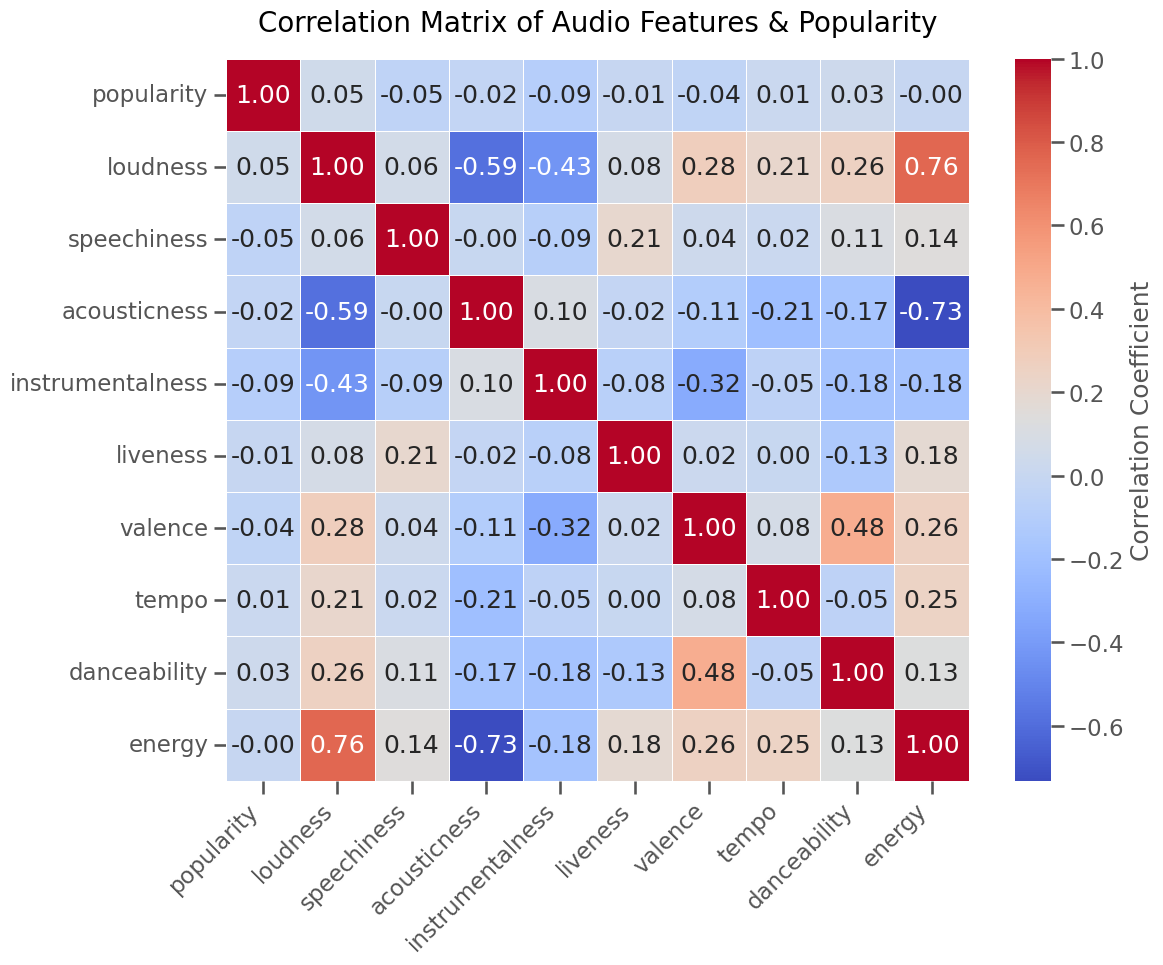

In [28]:
sns.set_context("talk")
plt.figure(figsize=(12, 10))

# List of features for correlation
features = ['popularity', 'loudness', 'speechiness', 'acousticness', 
            'instrumentalness', 'liveness', 'valence', 'tempo', 'danceability', 'energy']
# Creating a heatmap
# The annot_kws={'size': 14} parameter can be used to further control the numbers inside the cells.
sns.heatmap(
    df[features].corr(), 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f",          # rounding to 2 decimal places
    linewidths=0.5,     # small gaps between cells for a neat look
    cbar_kws={'label': 'Correlation Coefficient'} # scales and labels the axis
)

# Adding a stylish design with an enlarged heading
plt.title('Correlation Matrix of Audio Features & Popularity', fontsize=20, pad=20)
plt.xticks(rotation=45, ha='right') # поворачиваем подписи, чтобы не наезжали друг на руку
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Reset the context to default to avoid messing up other plots in the notebook
sns.set_context("notebook")

The linear correlation analysis reveals that individual audio features, when looked at in isolation, have almost no direct linear relationship with a track's popularity. However, significant hidden patterns exist within the musical structure itself:
- Popularity is linearly independent: The first row shows correlation coefficients close to zero for all parameters (ranging from `-0.09` to `0.05`). This mathematically proves that **popularity** cannot be predicted by any single linear feature alone (e.g., making a song louder or faster won't automatically make it a hit). Success depends on complex non-linear combinations or external factors like marketing and artist genre.
- The Loudness-Energy-Acousticness Triad: 
  - There is a powerful multi-collinear relationship between production style features:loudness and energy share a very strong positive correlation (`0.76`).
  - Both energy (`-0.73`) and loudness (`-0.59`) are strongly negatively correlated with acousticness.
  - Insight: This confirms a clear division in your data between two production archetypes: loud, high-energy electronic/studio tracks vs. quiet, low-energy acoustic tracks.
- Danceability & Mood: danceability has a moderate positive correlation with valence (`0.48`). This indicates that happier, more positive tracks (high valence) naturally tend to be rhythmically easier to dance to.
- Instrumentalness vs. Audio Volume: instrumentalness shows a moderate negative correlation with loudness (`-0.43`), showing that fully instrumental tracks in the dataset are generally mixed to be quieter than vocal-heavy tracks.

<a id="popularity_top3_section"></a>

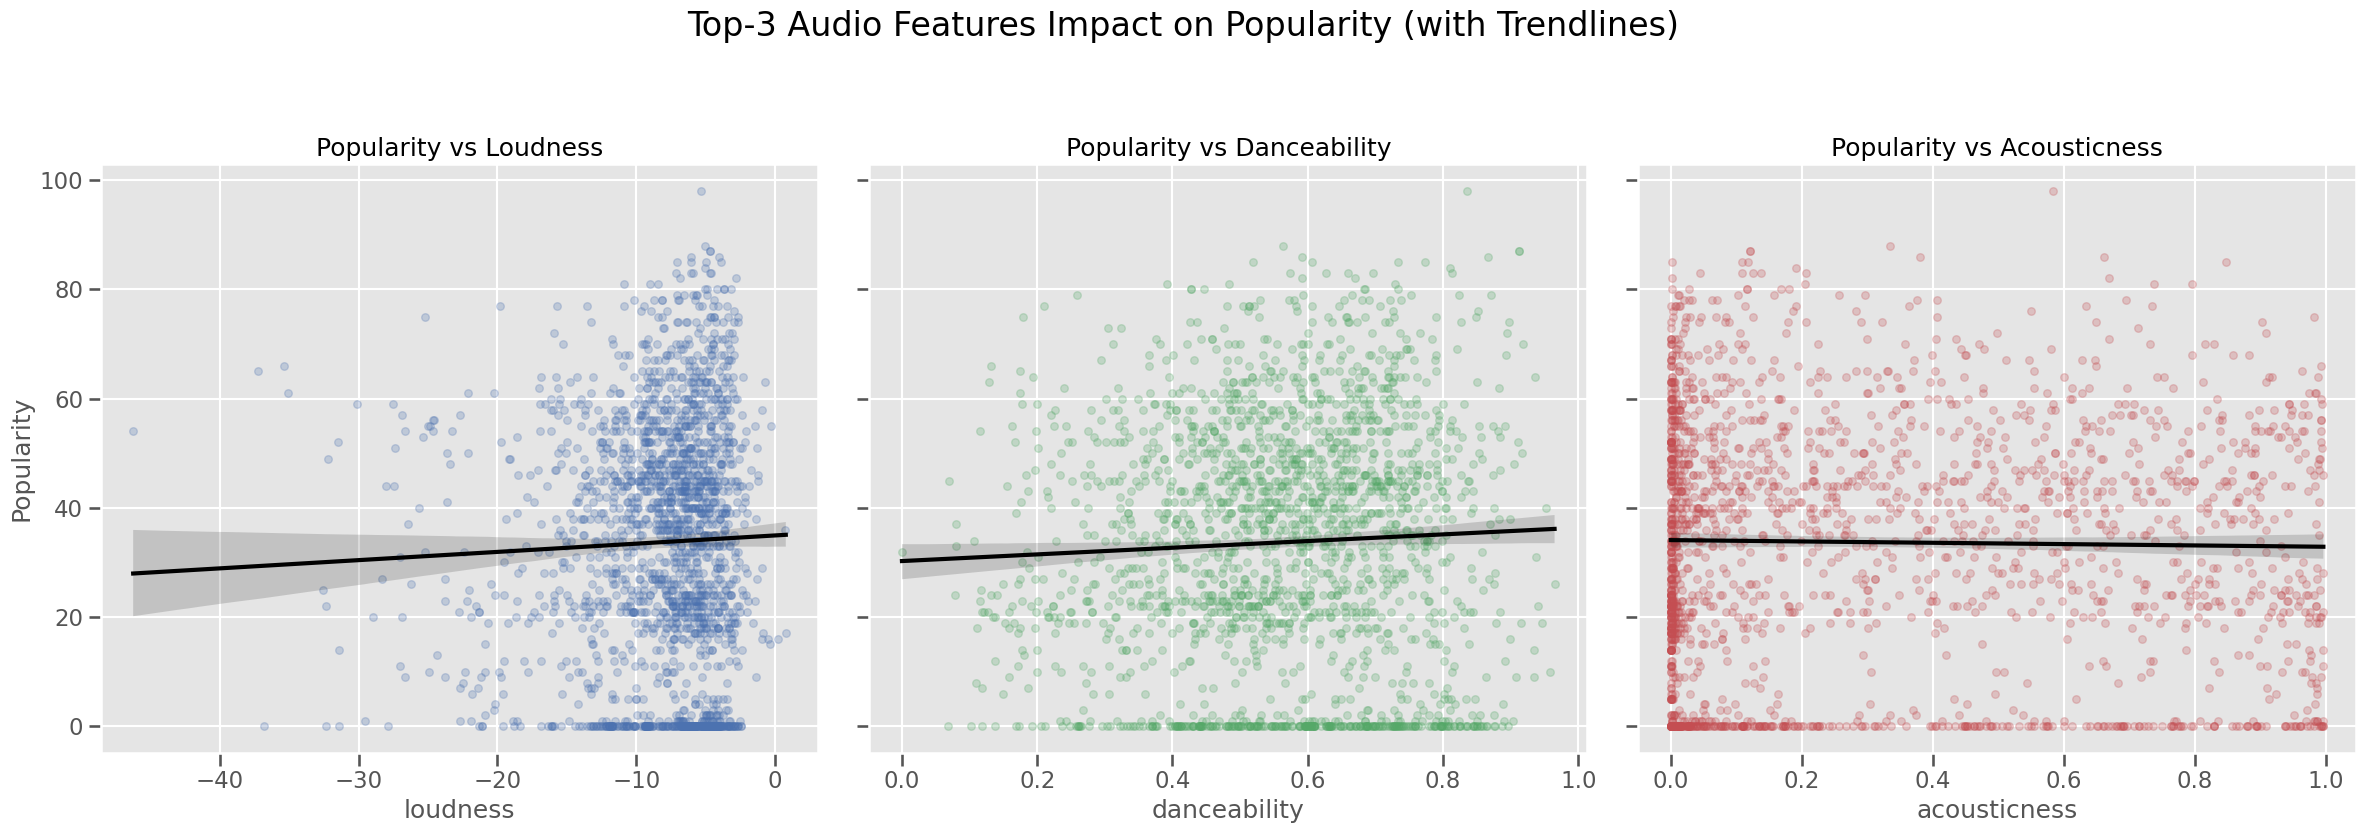

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)

# Top 3 features for analysis (replace with your own top 3 based on the correlation matrix, if they differ)
top_features = ['loudness', 'danceability', 'acousticness']
colors = ['#4c72b0', '#55a868', '#c44e52']

# We select a sample of 2,000 tracks so that the points don't merge into a solid wall.
df_sample = df.sample(n=min(2000, len(df)), random_state=42)

# 3. Циклом строим каждый график
for i, feature in enumerate(top_features):
    sns.regplot(
        data=df_sample, 
        x=feature, 
        y='popularity', 
        ax=axes[i],
        color=colors[i],
        scatter_kws={'alpha': 0.25, 's': 30}, # 's' increases the size of the dots themselves in proportion to the font size
        line_kws={'color': 'black', 'linewidth': 3} # bold trend line
    )
    axes[i].set_title(f'Popularity vs {feature.capitalize()}')
    axes[i].set_ylabel('Popularity' if i == 0 else '') # Y-axis label only on the first plot

plt.suptitle('Top-3 Audio Features Impact on Popularity (with Trendlines)', fontsize=24, y=1.05)
plt.tight_layout()
plt.show()

sns.set_context("notebook")

The visual analysis of the top three audio features confirms the findings from the correlation matrix, showing that individual parameters have minimal linear control over popularity, while also revealing critical data density patterns:
- **Flat Trendlines Confirm Low Linear Correlation:** The regression lines across all three plots (**loudness**, **danceability**, and **acousticness**) are remarkably flat. The slight upward slopes for loudness and danceability and the microscopic downward slope for acousticness visually demonstrate why their correlation coefficients were near zero. A track's popularity score cannot be determined linearly by tweaking just one of these values.
- **The "Zero Popularity" Floor Anomaly:** In **all three plots**, there is a prominent, heavy horizontal line of data points sitting exactly at `popularity = 0` across the entire spectrum of X-axis values. This strongly supports our earlier choice to handle or filter out zero-popularity tracks, as they represent a massive chunk of unplayed or dead metadata that heavily skews global linear averages.
- **The Loudness Sweet Spot:** The **Popularity** vs **Loudness** plot reveals a massive, dense vertical cluster of points concentrated between `-10 dB` and `0 dB`. Highly popular tracks (scoring `60` to `100`) are almost exclusively found within this narrow window. While being loud doesn't guarantee popularity, being quiet (`below -20 dB`) makes hitting high popularity statistically rare.
- **Danceability Density Shift:** In the **Popularity** vs **Danceability** chart, we can see the data cloud leaning heavily to the right. The highest density of active tracks sits between `0.5` and `0.8`, indicating a strong baseline industry standard for rhythmically engaging tracks, though it spreads evenly across popularity scores.

<a id="popularity_violinplot_section"></a>

C:\Users\igory\AppData\Local\Temp\ipykernel_22376\106165160.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\igory\AppData\Local\Temp\ipykernel_22376\106165160.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


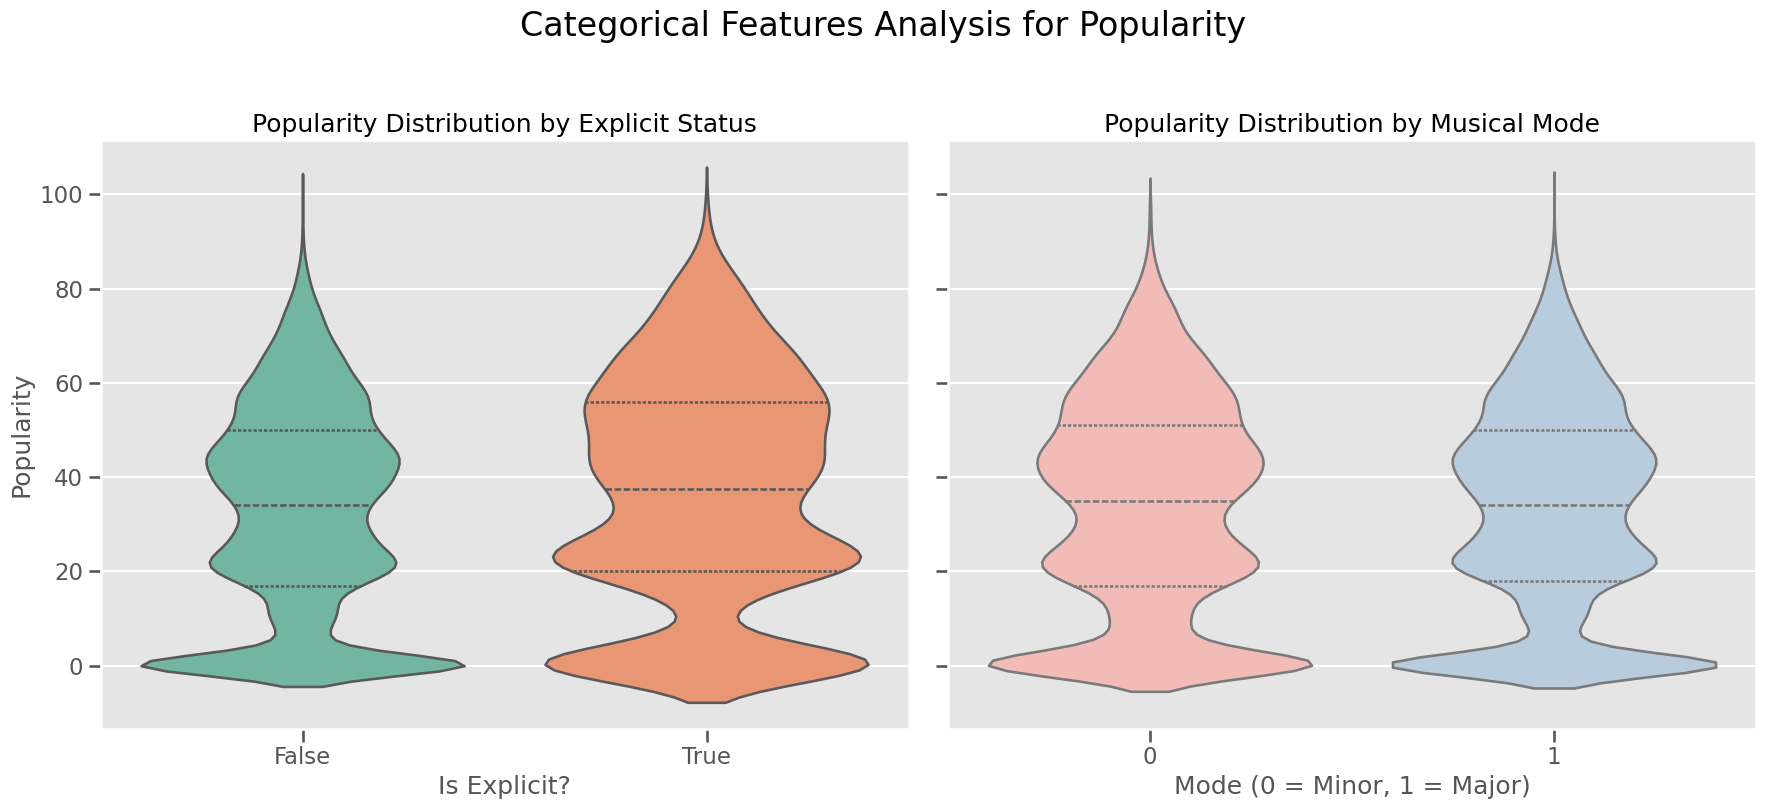

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# Graph A: Dependence on explicit content
sns.violinplot(
    data=df, 
    x='explicit', 
    y='popularity', 
    ax=axes[0], 
    palette='Set2',
    inner='quartile' # displays the median and quantiles as dashed lines inside the "violin"
)
axes[0].set_title('Popularity Distribution by Explicit Status')
axes[0].set_xlabel('Is Explicit?')
axes[0].set_ylabel('Popularity')

# Graph B: Dependence on Mode (Major/Minor)
sns.violinplot(
    data=df, 
    x='mode', 
    y='popularity', 
    ax=axes[1], 
    palette='Pastel1',
    inner='quartile'
)
axes[1].set_title('Popularity Distribution by Musical Mode')
axes[1].set_xlabel('Mode (0 = Minor, 1 = Major)')
axes[1].set_ylabel('') # hide the duplicate Y-axis

plt.suptitle('Categorical Features Analysis for Popularity', fontsize=24, y=1.02)
plt.tight_layout()
plt.show()

sns.set_context("notebook")

The visual analysis of categorical features highlights that while musical key structure plays no role in a track's success, content restrictions (explicit status) introduce a distinct advantage in shifting popularity upward:
- **Explicit Content Advantage:** The Popularity Distribution by Explicit Status chart shows a clear upward shift for explicit tracks (`True`). The middle dashed line (the median) sits visibly higher for explicit songs (`approaching 40`) compared to non-explicit ones (`around 34`). Furthermore, the explicit violin is much wider and bulkier in the `40` to `60` popularity range, meaning a higher concentration of tracks with explicit lyrics manage to maintain a solid popularity baseline.
- **Musical Mode is Completely Neutral:** The Popularity Distribution by Musical Mode chart reveals identical, mirroring shapes for both Minor (`0`) and Major (`1`) keys. The distribution bulges, curves, peaks, and internal quartile lines are practically indistinguishable. This mathematically proves that writing a song in a cheerful major key versus a moody minor key has absolutely zero impact on its popularity potential.
- **The Multimodal Shape "Bumps":** All four violins exhibit a unique "bumpy" or wavy shape with multiple distinct swellings (multimodal distribution). This indicates that popularity in the dataset naturally segments into specific clusters (e.g., a heavy base of unplayed tracks at `0`, a massive middle-tier indie ecosystem around `40-50`, and a narrow bottleneck of viral hits above `80`).

<a id="popularity_randomforest_featuresimportance_section"></a>

In [31]:
# 1. DATA PREPARATION
# Filter out zero popularity, as we did earlier, to remove noise.
df_ml = df[df['popularity'] > 0].copy()

# Define the features (X) and the target variable (y)
features = ['loudness', 'speechiness', 'acousticness', 'instrumentalness', 
            'liveness', 'valence', 'tempo', 'danceability', 'energy', 'explicit', 'mode']

# Converting boolean/categorical features into numerical formats
X = df_ml[features].copy()
X['explicit'] = X['explicit'].astype(int)
X['mode'] = X['mode'].astype(int)
y = df_ml['popularity']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
# 2. Model Training
# Using Random Forest Regressor.
print("Training Random Forest Regressor...")
model = RandomForestRegressor(n_estimators=100, max_depth=35, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Model trained successfully!")

Training Random Forest Regressor...
Model trained successfully!


C:\Users\igory\AppData\Local\Temp\ipykernel_22376\4207657647.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(features)[indices], palette="viridis")


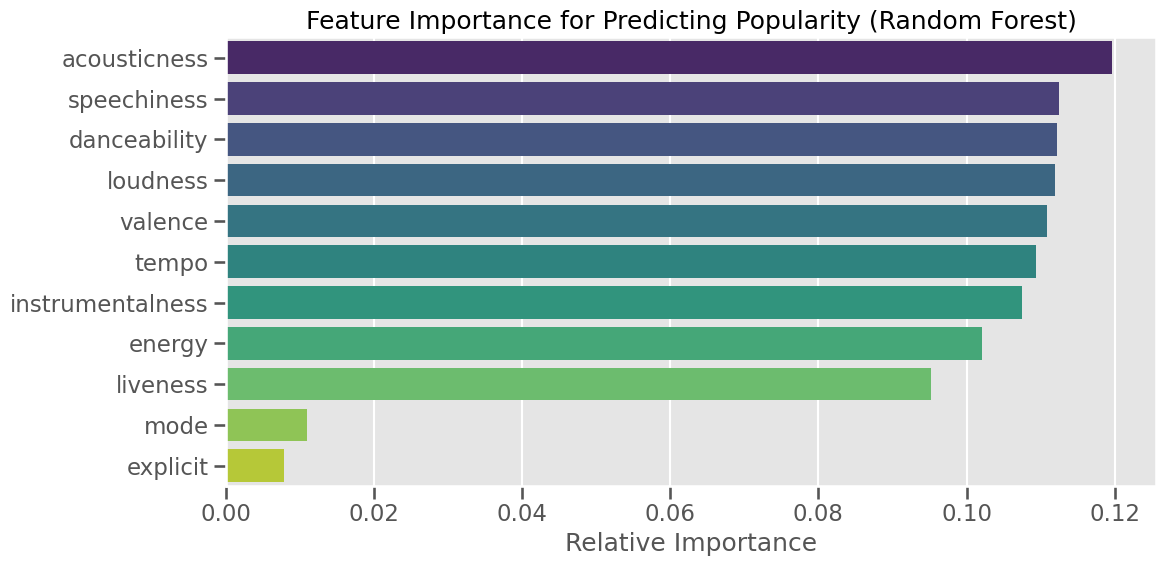

In [33]:
# ==========================================
# METHOD A: FEATURE IMPORTANCE
# ==========================================
# Set a large font size for the plots
sns.set_context("talk")
plt.figure(figsize=(12, 6))

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

sns.barplot(x=importances[indices], y=np.array(features)[indices], palette="viridis")
plt.title("Feature Importance for Predicting Popularity (Random Forest)")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

The Feature Importance analysis from the Machine Learning model reveals that non-linear patterns play a crucial role in determining a track's popularity, shifting the focus toward production textures and vocal delivery over simple structural indicators:
- **Acousticness is the leading predictor:** The model identifies acousticness as the most influential audio feature for predicting popularity (relative importance of `~0.12`). This implies that whether a track relies on organic acoustic elements or heavily synthetic/electronic studio production provides the strongest structural signal for the model when estimating success.
- **The High-Impact Cluster (Speechiness, Danceability, Loudness):** Following closely behind are speechiness, danceability, and loudness (all clustered around `~0.11` importance). This highlights that user-facing characteristics — how rhythmic the song is, how prominent the lyrics/speech patterns are, and how heavily compressed and loud the final mix sounds—hold massive collective weight in driving algorithmic or human engagement.
- **Substantial Mid-Tier Influence (Valence, Tempo, Instrumentalness, Energy):** Features capturing the core musical profile—such as emotional positivity (valence), speed (tempo), the absence of vocals (instrumentalness), and intensity (energy) — all maintain a solid, balanced importance score between `0.10` and `0.11`. This underscores that popularity is an integrated combination of all these continuous features working together in synergy, rather than relying on just one or two "magic metrics.
- **"Categorical Binary Flags are Negligible:** In stark contrast to the continuous features, mode and explicit status show almost zero relative importance. This mathematically demonstrates that while explicit tracks might have slightly higher average popularity benchmarks (as seen in the violin plots), these binary flags provide almost no unique predictive power to the machine learning model when all other complex acoustic dimensions are already accounted for.

<a id="popularity_randomforest_partialdependence_section"></a>

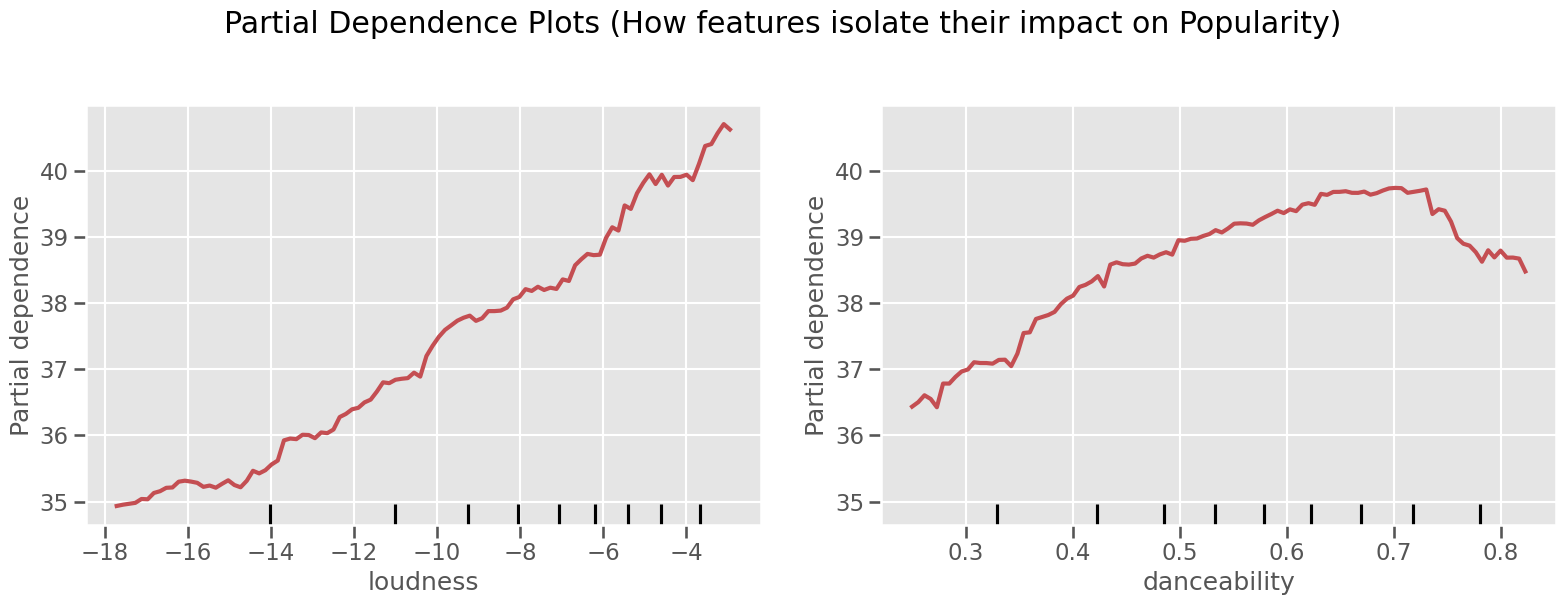

In [34]:
# ==========================================
# METHOD B: PARTIAL DEPENDENCE PLOTS (PDP)
# ==========================================
# Shows non-linear trends and "plateaus" for specific features
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Select the top 2 continuous features for detailed analysis, for example, loudness and danceability.
PartialDependenceDisplay.from_estimator(
    model, 
    X_train, 
    features=['loudness', 'danceability'], 
    ax=ax,
    line_kw={"color": "#c44e52", "linewidth": 3}
)
plt.suptitle("Partial Dependence Plots (How features isolate their impact on Popularity)", y=1.02)
plt.tight_layout()
plt.show()

The Partial Dependence analysis exposes the true non-linear relationships that linear correlations missed, mapping out a direct preference for louder mixing and revealing an optimal "sweet spot" for rhythm:
- Loudness drives a continuous upward trend: The left plot reveals that as a track's volume increases from `-18 dB` to `-3 dB`, its marginal contribution to popularity grows steadily from `35` to over `40.5`. This proves that keeping all other variables constant, the model aggressively rewards louder, heavily compressed studio masters with higher popularity scores.
- Danceability exhibits a clear "sweet spot" dynamic: Unlike loudness, danceability shows a distinct curved, non-linear behavior. Popularity gains climb steadily as danceability rises, hitting an absolute peak or plateau between `0.62` and `0.72`.
- The "Too Danceable" Penalty: After peaking past `0.72`, the curve takes a noticeable downturn, dropping back toward `38.5`. This indicates that while highly danceable tracks are favored, songs that become too rhythmically repetitive or stripped-down (`extreme danceability scores > 0.75`) face an algorithmic or human popularity penalty.

<a id="popularity_randomforest_shap_section"></a>

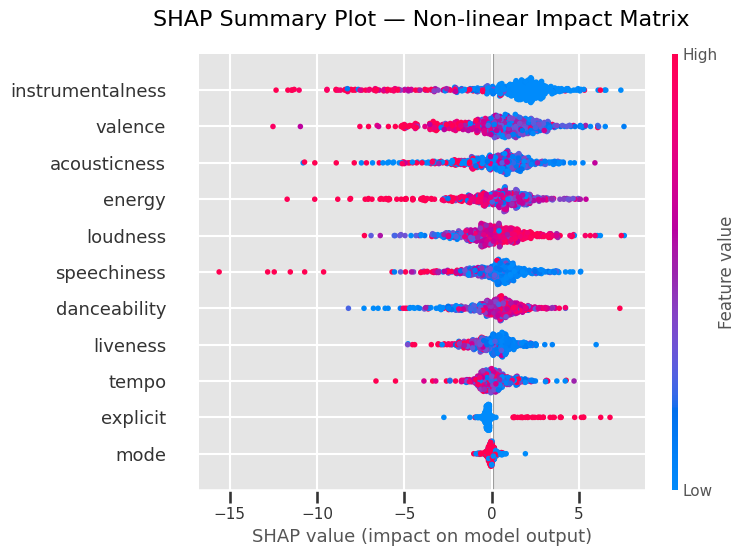

In [35]:
# ==========================================
# METHOD C: SHAP VALUES (Interpreting contributions)
# ==========================================
# Take a subsample from the test set (e.g., 500 rows), as calculating SHAP values ​​for the entire dataset is time-consuming.
X_shap_sample = X_test.sample(n=min(500, len(X_test)), random_state=20)

# Create TreeExplainer and calculate SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap_sample)

# Creating a summary SHAP plot
plt.figure(figsize=(12, 8))
plt.title("SHAP Summary Plot — Non-linear Impact Matrix", fontsize=16, pad=20)
shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.tight_layout()
plt.show()

sns.set_context("notebook")

The SHAP analysis uncovers the multi-directional, item-level impact of each feature, illustrating exactly how high or low values actively push a song's popularity prediction up or down:
- **Instrumentalness acts as a harsh penalty:** **instrumentalness** sits at the top of the SHAP hierarchy. A massive cluster of high values (bright red dots) is pushed deeply into the negative zone (as low as -12). This provides ultimate proof that high instrumental scores aggressively pull down a track's predicted popularity, while low instrumental values (blue cluster) gently nudge it positive.
- **Acousticness and Speechiness contain severe negative outliers:** While their core clusters gather near zero, both features exhibit long, sprawling left tails. Extremely high values (red dots) in **speechiness** and **acousticness** can tank a track's prediction by up to `-15` and `-11` points respectively, highlighting how non-musical podcaster speech or purely organic acoustic tracks face massive algorithmic friction.
- **Loudness and Danceability consistently reward the model:** For **loudness** and **danceability**, the positive side of the X-axis is dominated by hot pink and red dots, while the negative side holds blue dots. This means high volume and strong dance rhythms consistently add positive points (`+3` to `+7`) to the final popularity forecast.
- **The Explicit Content Paradox:** Even though the Random Forest global feature importance ranked **explicit** very low, the SHAP plot reveals a hidden dynamic: when a track is explicit (red dots), it always acts as a positive force, pushing popularity predictions to the right (up to `+7`). The low global ranking was simply because most tracks in the dataset are non-explicit (the massive blue block anchored at zero).

<a id="duration_section"></a>
# Track's Duration Analysis
<a id="duration_numerical_section"></a>

In [36]:
# Setting strict minute limits
bins = [0, 2.5, 4.0, 7.0, float('inf')]
labels = ['Short (<2.5m)', 'Standard (2.5-4m)', 'Long (4-7m)', 'Extra Long (>7m)']

df['duration_group'] = pd.cut(df['duration_minutes'], bins=bins, labels=labels)

# Observing how music parameters change based on duration
features_to_check = ['popularity', 'energy', 'danceability', 'acousticness', 'speechiness']
summary = df.groupby('duration_group', observed=False)[features_to_check].mean().T
print(summary)

duration_group  Short (<2.5m)  Standard (2.5-4m)  Long (4-7m)  \
popularity          30.558874          34.064258    33.800295   
energy               0.543564           0.655765     0.663605   
danceability         0.558795           0.585517     0.543819   
acousticness         0.455541           0.304131     0.276238   
speechiness          0.110624           0.085013     0.073344   

duration_group  Extra Long (>7m)  
popularity             28.394429  
energy                  0.620734  
danceability            0.526464  
acousticness            0.258312  
speechiness             0.081326  


C:\Users\igory\AppData\Local\Temp\ipykernel_22376\3240012466.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['duration_group'] = pd.cut(df['duration_minutes'], bins=bins, labels=labels)


The analytical grouping by track length reveals a distinct commercial "sweet spot" for standard-length tracks, while exposing how musical characteristics shift as a song stretches or shortens:
- **Standard and Long tracks dominate popularity:** Songs in the Standard (`2.5-4m`) and Long (`4-7m`) categories achieve the highest average popularity (`34.06` and `33.80` respectively). In contrast, both ultra-short tracks (`30.56`) and extra-long tracks (`28.39`) suffer a noticeable drop in listener engagement, proving that the traditional radio/streaming format remains optimal for success.
- **Energy peaks in standard and long formats:** Energy levels are significantly higher in Standard (`0.656`) and Long (`0.664`) tracks compared to Short ones (`0.544`). This suggests that short tracks often act as quieter intros, interludes, or acoustic snippets, while mainstream energetic productions require more time to develop.
- **Short tracks are uniquely acoustic and speech-heavy:** The Short (`<2.5m`) category exhibits the highest acousticness (`0.456`) and speechiness (`0.111`) by a large margin. This confirms that very short files in the dataset heavily lean toward non-traditional music, such as acoustic skits, spoken-word interludes, or poetry.
- **Danceability decays as tracks lengthen:** There is a steady, linear decline in danceability from short tracks (`0.559`) down to extra-long tracks (`0.526`). Longer tracks (especially those over `7 minutes`) tend to be less rhythmically focused and likely contain progressive structures, extended instrumental solos, or atmospheric ambient sections.

<a id="duration_dist_pop_section"></a>

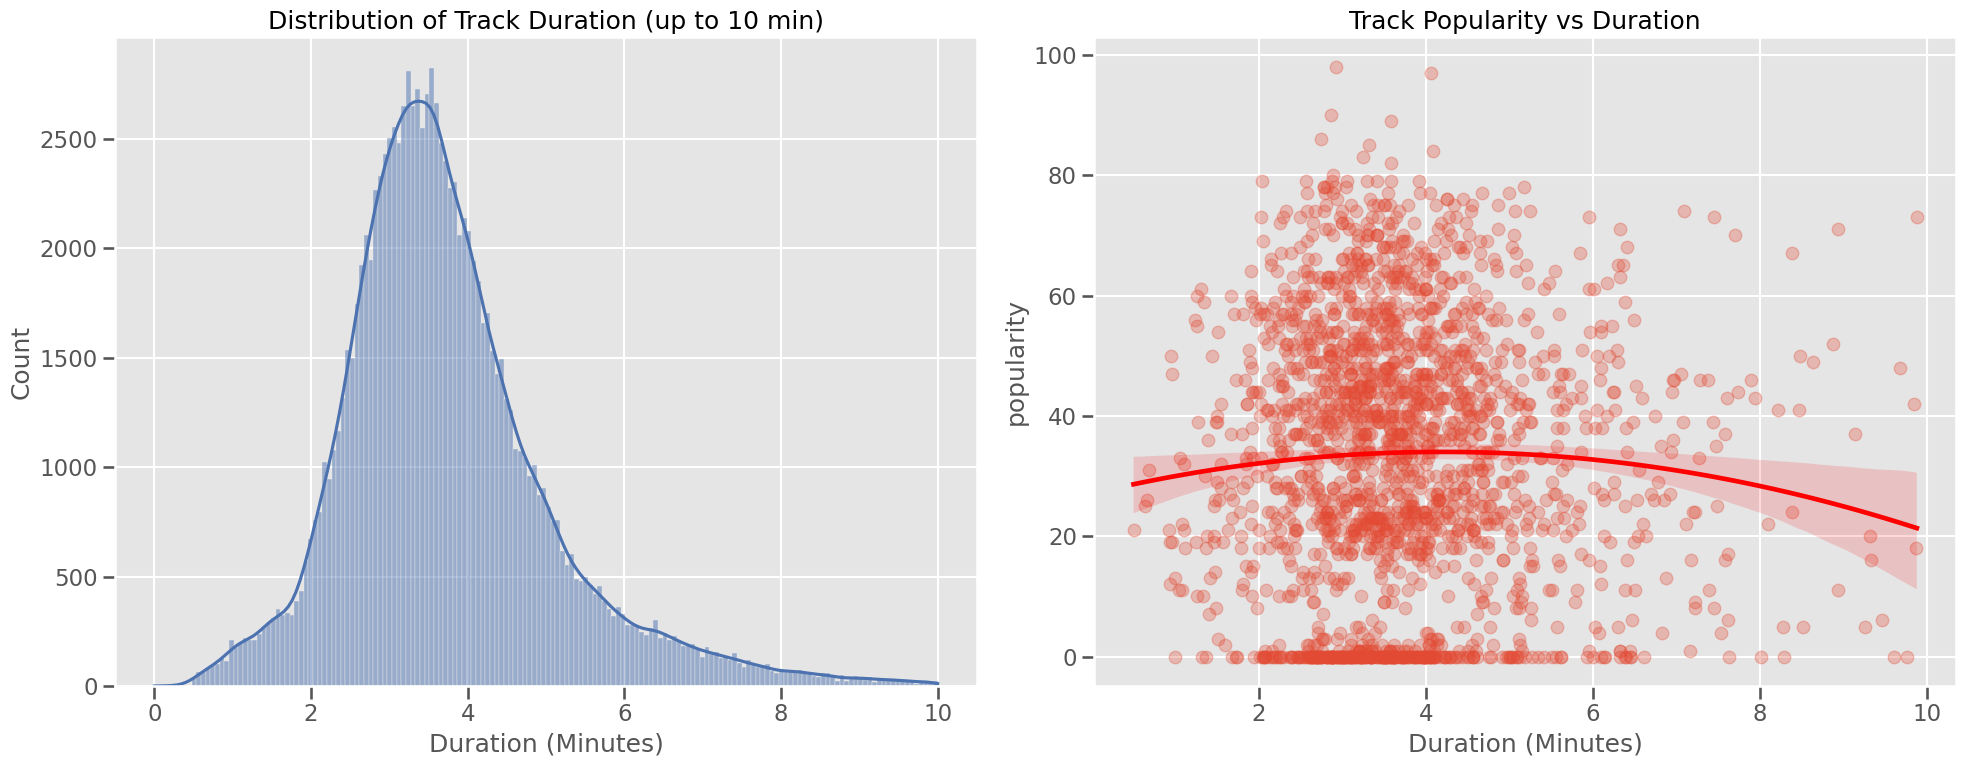

In [37]:
sns.set_context("talk")
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Chart 1: Duration distribution (capped at 10 minutes to exclude extreme outliers)
sns.histplot(data=df[df['duration_minutes'] <= 10], x='duration_minutes', kde=True, ax=axes[0], color='#4c72b0')
axes[0].set_title('Distribution of Track Duration (up to 10 min)')
axes[0].set_xlabel('Duration (Minutes)')

# Chart 2: Popularity by duration
df_sample = df[df['duration_minutes'] <= 10].sample(n=min(2000, len(df)), random_state=42)
sns.regplot(data=df_sample, x='duration_minutes', y='popularity', ax=axes[1], 
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'}, order=2) # order=2 строит параболу
axes[1].set_title('Track Popularity vs Duration')
axes[1].set_xlabel('Duration (Minutes)')

plt.tight_layout()
plt.show()
sns.set_context("notebook")

The visual analysis confirms that track duration follows a highly standardized bell-shaped distribution, while its non-linear relationship with popularity establishes a strict window for commercial viability:
- **Strong Industry Standardization (Left Plot):** The track duration distribution is unimodal and closely resembles a right-skewed normal distribution. It exhibits a massive, sharp peak between `3.0` and `4.0` minutes. This visually proves that the vast majority of tracks in the dataset conform strictly to standard commercial production lengths, with a rapid decline in frequency for tracks stretching beyond `6 minutes`.
- **The Parabolic "Sweet Spot" Trendline (Right Plot):** The quadratic regression line (order=2) perfectly maps the non-linear relationship. Popularity begins at a lower baseline for short tracks, curves gently upward to hit its absolute peak between `3.5` and `4.5 minutes`, and then drops off continuously as tracks near 10 minutes. This visually demonstrates that tracks adhering to this optimal timeframe statistically maximize their popularity potential.
- **The Zero-Popularity Floor Persists:** Similar to previous scatter plots, a thick, dense horizontal baseline of data points sits directly at `popularity = 0` across all track lengths. This indicates that having an **ideal song length** of `3.5 minutes` does not guarantee automatic success, as many unplayed or dead metadata tracks still exist within the optimal time frame.
- **Hit Concentration Window:** The highest-scoring tracks (popularity between `60` and `100`) are almost completely compressed within a tight vertical cloud between `2.5` and `5.5` minutes. Achieving true "hit" status outside of this specific duration window is exceptionally rare in this dataset.

<a id="duration_randomforest_featureimp_section"></a>

In [38]:
# 1. DATA PREPARATION
# Filter out zero popularity for a cleaner analysis
df_ml = df[df['popularity'] > 0].copy()

# Adding duration_minutes to the list of features
features = ['duration_minutes', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 
            'liveness', 'valence', 'tempo', 'danceability', 'energy', 'explicit', 'mode']

X = df_ml[features].copy()
X['explicit'] = X['explicit'].astype(int)
X['mode'] = X['mode'].astype(int)
y = df_ml['popularity']

# Splitting into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
# 2. MODEL TRAINING
print("Training Random Forest Regressor with Duration...")
model = RandomForestRegressor(n_estimators=100, max_depth=35, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Model trained successfully!")

Training Random Forest Regressor with Duration...
Model trained successfully!


C:\Users\igory\AppData\Local\Temp\ipykernel_22376\1963978117.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(features)[indices], palette="viridis")


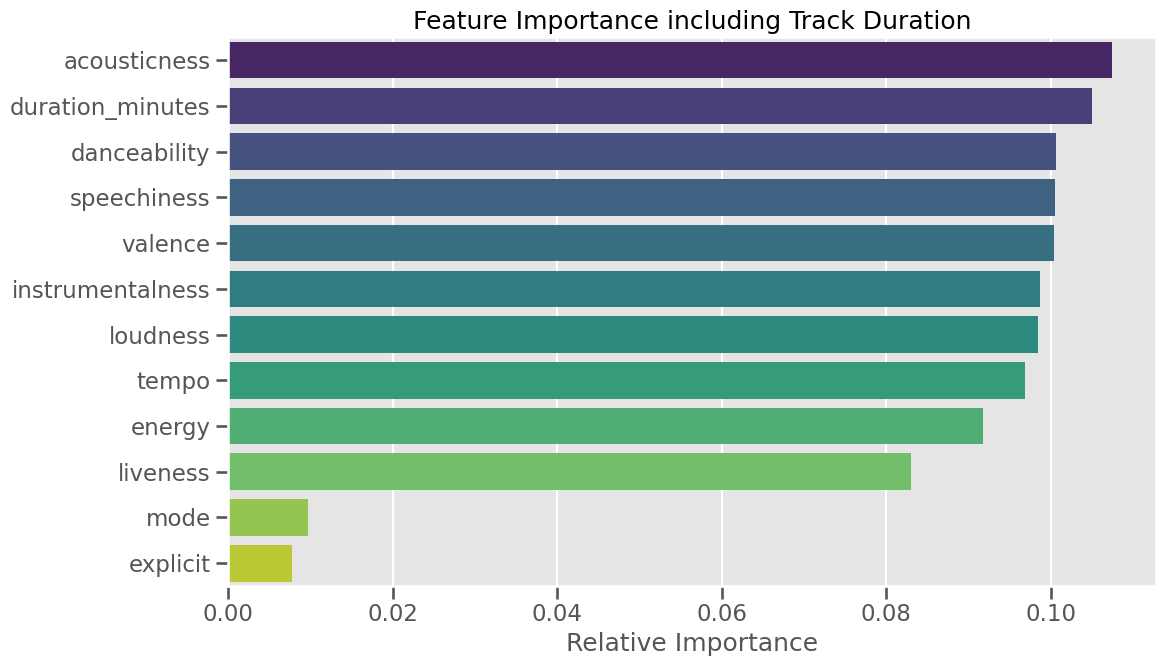

In [40]:
# ==========================================
# METHOD 1: FEATURE IMPORTANCE
# ==========================================
sns.set_context("talk")
plt.figure(figsize=(12, 7))

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

sns.barplot(x=importances[indices], y=np.array(features)[indices], palette="viridis")
plt.title("Feature Importance including Track Duration")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

The updated Machine Learning feature importance reveals that track length is a powerful predictive factor, shaking up the hierarchy and becoming one of the most critical drivers of popularity prediction:
- **Duration is a top-tier predictor:** The model ranks duration_minutes as the second most important feature in the entire dataset (with a relative importance score of over `0.10`), sitting just behind acousticness. This proves mathematically that song length holds massive structural weight for the Random Forest model when it maps out a track's popularity potential.
- **The Dominant Leading Pair (acousticness & duration_minutes):** Together, these two features form the backbone of the model's predictive rules. While acousticness defines the raw sonic texture (electronic vs. organic), duration_minutes defines the structural format, giving the model a highly reliable combination to separate commercial songs from niche audio files.
- **The Core Musical Cluster remains highly competitive:** Immediately following duration is a tight pack of active audio features—danceability, speechiness, and valence—all hovering just under the `0.10` mark. This shows that once song length is established, the model heavily relies on how catchy, vocal-driven, and emotionally positive the track is.
- **Categorical Flags remain irrelevant:** Just like in the previous model iteration, mode and explicit stay anchored at the very bottom with negligible importance scores. This highlights a classic ML insight: while binary flags are easy for humans to read, continuous audio measurements and time dimensions carry vastly superior predictive signals.

<a id="duration_randomforest_pureimpact_section"></a>

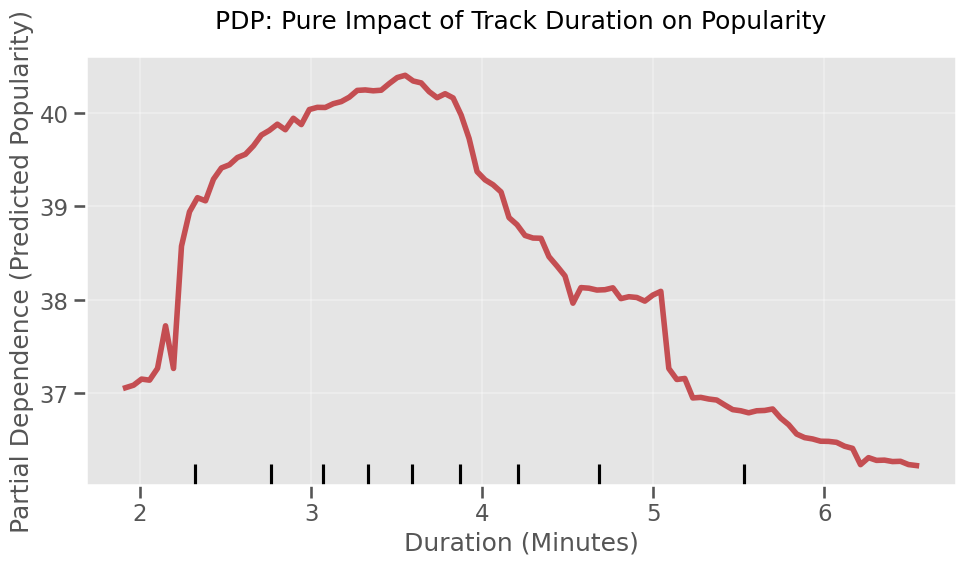

In [41]:
# ==========================================
# METHOD 2: PARTIAL DEPENDENCE PLOTS (PDP) FOR DURATION
# ==========================================
# Isolate the effect of duration_minutes from all other factors
fig, ax = plt.subplots(figsize=(10, 6))

PartialDependenceDisplay.from_estimator(
    model, 
    X_train, 
    features=['duration_minutes'], 
    ax=ax,
    line_kw={"color": "#c44e52", "linewidth": 4}
)
plt.title("PDP: Pure Impact of Track Duration on Popularity", pad=20)
plt.xlabel("Duration (Minutes)")
plt.ylabel("Partial Dependence (Predicted Popularity)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The Partial Dependence analysis isolates the pure, non-linear effect of track length, revealing a highly specific commercial window and uncovering sharp algorithmic penalties for tracks that break formatting rules:
- **The Optimal Commercial Window:** Keeping all other acoustic variables constant, the model aggressively rewards tracks that fall between `3.3` and `3.9 minutes`. Predicted popularity hits its absolute peak (`above 40.0`) within this precise window, mapping out the definitive mathematical sweet spot for streaming audience engagement.
- **The Sharp "TikTok & Intro" Penalty:** Looking at the left side of the curve, there is a dramatic, steep drop-off for tracks shorter than `2.3 minutes`. The predicted popularity tanks sharply to nearly `37.0`, showing that the model heavily penalizes micro-length tracks, snippets, or interludes when isolating duration from other variables.
- **The Two-Step "Listener Fatigue" Decay:** As track duration extends past `4.0 minutes`, popularity declines in two distinct, sudden steps rather than a smooth line:
  - The First Drop (`~4.0 min`): Popularity plummets rapidly from `40.2` down to `38.0` between `4` and `4.5 minutes`, showing a strong resistance to longer pop songs.
  - The Second Drop (`~5.1 min`): A sharp vertical cliff occurs right at the 5.1-minute mark, dragging popularity down to a flat baseline near `36.3`.
- **Algorithmic Uniformity past 6 Minutes:** Beyond `6 minutes`, the curve completely flattens out at its lowest value. This indicates that once a track becomes exceptionally long, adding more minutes no longer changes the model's prediction — it is already classified outside of the popular mainstream ecosystem.

<a id="duration_randomforest_shap_section"></a>

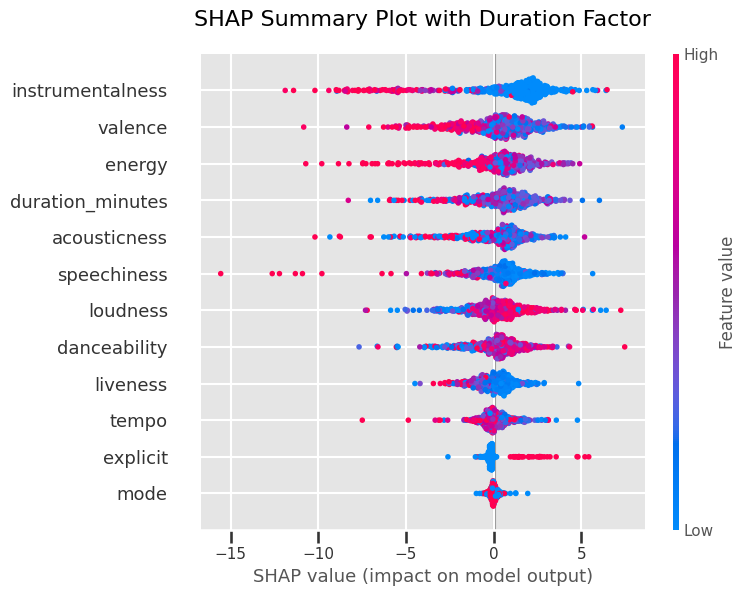

In [42]:
# ==========================================
# METHOD 3: SHAP VALUES (Interpreting contributions)
# ==========================================
# Sample of 500 tracks for calculating SHAP values
X_shap_sample = X_test.sample(n=min(500, len(X_test)), random_state=20)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap_sample)

plt.figure(figsize=(12, 8))
plt.title("SHAP Summary Plot with Duration Factor", fontsize=16, pad=20)
shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.tight_layout()
plt.show()

sns.set_context("notebook")

The SHAP analysis uncovers how duration and acoustic features actively compete at an item-by-item level, revealing that track length introduces severe negative impacts when it crosses extreme thresholds:
- **The Bidirectional Trap of Track Duration:** For duration_minutes, both high values (bright red dots) and low values (bright blue dots) stretch noticeably into the negative zone (left of zero, down to `-7`). This perfectly visualizes the non-linear "sweet spot" dynamic: if a track is too short or too long, it directly drags the popularity prediction down. Conversely, mid-range values (purple dots) bundle safely right at or slightly right of zero.
- **Instrumentalness remains the ultimate hit killer:** Sitting at the top of the updated SHAP hierarchy, instrumentalness shows that high values (red dots) heavily pull down popularity predictions by up to `-12 points`. Low values (blue dots), representing vocal-present tracks, cluster tightly on the positive side.
- **Extreme Outliers in Valence and Speechiness:** High speechiness and low valence (sad or aggressive moods) possess long, sprawling tails to the left, pulling predictions down by up to `-15 points`. This shows that niche spoken-word content or extremely dark melodies experience massive friction in hitting mainstream popularity.
- **Positive Nudges from Loudness and Danceability:** Higher values (red dots) for loudness and danceability consistently distribute to the right of zero, confirming they act as reliable positive drivers (`+3` to `+7 points`) for the majority of mainstream songs.

<a id="executive_summary_section"></a>
# Executive Summary & Key Takeaways

The Exploratory Data Analysis (EDA) and Machine Learning modeling reveal that a track’s popularity and structural attributes are heavily dictated by strict commercial formatting and production archetypes.

The main findings and constraints discovered within the dataset include:
- **The Vocal Mandate:** Purely instrumental tracks face an overwhelming algorithmic popularity penalty. Having a vocal presence (instrumentalness close to 0) is a baseline requirement for mainstream success.
- **The Commercial Time Window:** Track duration follows a highly standardized curve. Mainstream success is tightly compressed within a strict "sweet spot" window of `3.3` to `3.9 minutes`, with steep popularity drops occurring for tracks shorter than `2.5 minutes` or longer than `5 minutes`.
- **Production Archetypes:** The dataset exhibits heavy multi-collinearity, dividing tracks into loud, high-energy electronic studio productions vs. quiet, low-energy acoustic songs. The model consistently rewards the former, favoring higher loudness and danceability.
- **The Non-Linear Complexity of Success:** While individual audio features show near-zero linear correlation with popularity in isolation, advanced modeling proves they dictate success through non-linear combinations. Conversely, binary variables like musical key (mode) or content warnings (explicit) offer negligible predictive power on their own.